# COSC102 Assessment 3: Machine Learning Portfolio
## Comparing the Performance of Machine Learning Approaches for Activity Classification

**Unit:** COSC102 Data Science Studio 1, Trimester 2 2026
**Group 1:** Ash Kuinkel · Davina Prasad · Dre Tomek

#### Purpose

This portfolio takes raw inertial measurement unit (IMU) readings of a
person performing five physical activities, aligns them against a hand-annotated
video of the same session, and trains machine learning classifiers to recognise the
activity from the sensor signal alone. It follows the workflow demonstrated in
Tutorial 05 (*Activity Recognition*) and extends it with a derived alignment, a
larger classifier set, and hyperparameter optimisation.

| Section | Content | Author |
|---|---|---|
| 1 | Data pipeline: loading, alignment, trimming, labelling, dataset visualisation | Dre Tomek |
| 2 | Feature engineering: moving-window features over accelerometer and gyroscope | Davina Prasad |
| 3 | Modelling: classifiers, hyperparameter optimisation, performance comparison | Ash Kuinkel |
| 4 | Conclusion | All |

#### The dataset

A SparkFun 9DoF Razor IMU logged tri-axial accelerometer and
gyroscope readings to an SD card while a video recorded the session. The video was
annotated in VoTT, producing a list of activity start times in *video* time. The two
files do not share a clock, which is the first problem Section 1 has to solve.

---

# Section 1. Data pipeline

*Author: Dre Tomek*

The IMU file and the annotation file describe the same twelve minutes of activity,
but they are not on the same clock and they do not start together:

* IMU timestamps are Unix epoch seconds (`1598240213` …).
* Annotation timestamps are seconds into the video (`0.0`, `66.2`, `75.4` …).

The logger was switched on before recording started and switched off after it
finished, so the IMU file also contains material either side of the video that no
annotation covers. Section 1 resolves the offset between the two clocks, trims the
IMU data to the window the video actually covers, assigns an activity label to every
remaining sample, and checks the result visually before handing it to Section 2.

### 1.1 Configuration

Every value that changes the pipeline's *output* lives here, so no result depends on a
literal buried further down. `QUIET_THRESHOLD` and `MIN_QUIET_RUN` control the
stationary detector in §1.4, `BUCKET_SPAN_S` the labelling rule in §1.6, and
`VIDEO_DURATION_S` was read from the annotation video's container metadata with
`ffprobe`. Presentation-only values (figure sizes, colours) sit here too but change
nothing computed. Plot-local literals such as axis extents are left where they are
used, since hoisting them would spread one figure's layout across two cells.

In [1]:
import csv
import math
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- Paths -------------------------------------------------------------
DATA_DIR = "data"
FRAME_DIR = "frames"
IMU_FILE = os.path.join(DATA_DIR, "a3_imu_data.csv")
ANNOTATION_FILE = os.path.join(DATA_DIR, "a3_activity_annotations.csv")

# ---- Dataset facts -----------------------------------------------------
# Column order of the headerless IMU export.
IMU_COLUMNS = ["timestamp", "ax", "ay", "az", "gx", "gy", "gz"]
ACCEL_AXES = ["ax", "ay", "az"]
GYRO_AXES = ["gx", "gy", "gz"]

# The only annotated activity during which the sensor is stationary. §1.4
# aligns the two clocks by reconciling this class against the IMU signal.
REST_LABEL = "Standing"

# Length of a3_annotations.mkv, from its container metadata.
VIDEO_DURATION_S = 711.45

# One IMU timestamp bucket. The logger stamps whole seconds, so all the
# readings sharing a timestamp cover this span of real time. §1.6 needs it
# to label a bucket by its middle rather than its leading edge.
BUCKET_SPAN_S = 1.0

# ---- Alignment parameters (§1.4) ---------------------------------------
# 0.10 was read off the motion plot rather than derived. Anything from
# 0.05 to 0.20 puts the offset inside 8.45-8.70 s, so the exact cut is not
# load-bearing; the minimum run length matters more.
QUIET_THRESHOLD = 0.10      # normalised motion below this reads as stationary
MIN_QUIET_RUN = 3           # three seconds, because two catches a stride pause
OFFSET_SEARCH_S = (0.0, 20.0)
OFFSET_STEP_S = 0.05
OFFSET_BAND_POINTS = 0.025  # score points either side of the peak, in §1.4

# ---- Data quality (§1.8) -----------------------------------------------
NOMINAL_RATE_HZ = 100       # the brief's stated sampling rate
# Half the nominal rate is a judgement call, not a derived cut. It sits well
# clear of the 9-sample second and well below the 100-sample median, which is
# all it needs to do - the count travels with the data either way.
THIN_SECOND_RATIO = 0.5     # under this share of NOMINAL_RATE_HZ counts as thin

# ---- Presentation ------------------------------------------------------
AXIS_COLOURS = ["#d1495b", "#2e933c", "#3f88c5"]
FIG_WIDE = (16, 6)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 10})

### 1.2 Loading the IMU data

The export has no header row, so the column names come from the assessment brief.
Readings are raw 16-bit signed integers from the sensor (±8 g on the accelerometer,
±8000 degrees per second on the gyroscope). They are left in raw units here, because
converting to g and degrees per second is a fixed linear rescale of each axis and
every feature Section 2 computes is either a linear statistic or a magnitude, so the
conversion would change the numbers without changing anything a classifier can learn.

Keeping the raw units is not the same as saying scale does not matter. Accelerometer and
gyroscope features end up on different numerical ranges, and the brief's candidate classifiers
include KNN and SVM, both of which measure distances across features and will be
dominated by whichever range is larger. Section 3 needs an explicit scaling step
(`StandardScaler` inside a pipeline, fitted on the training split only). Tree-based
models are indifferent. This is a Section 3 obligation that Section 1 is deliberately
not pre-empting, noted here so it is not discovered by accident.

In [2]:
#########################################################################
# load_imu_readings(path, columns)
#
# Reads the headerless IMU export into a DataFrame and adds the two
# derived columns the rest of the pipeline works from:
#
#   second - whole seconds elapsed since the first reading, which is the
#            finest resolution the timestamps actually carry
#   a_mag  - accelerometer vector magnitude
#   g_mag  - gyroscope vector magnitude
#
# Raises if the file is missing or its timestamps run backwards, since
# every later step assumes the readings are chronological.
#
# Returns the DataFrame.
#########################################################################

def load_imu_readings(path, columns):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found. Run this notebook from its own directory, "
            f"which is where data/ sits (currently {os.getcwd()}).")

    readings = pd.read_csv(path, header=None, names=columns)
    if not readings["timestamp"].is_monotonic_increasing:
        raise ValueError("IMU timestamps are not in order; every downstream "
                         "step assumes the file is chronological")

    readings["second"] = (readings["timestamp"]
                          - readings["timestamp"].min()).astype(int)
    # Precomputed; §1.4 and §1.7 both want them.
    readings["a_mag"] = np.linalg.norm(readings[ACCEL_AXES], axis=1)
    readings["g_mag"] = np.linalg.norm(readings[GYRO_AXES], axis=1)
    return readings


imu = load_imu_readings(IMU_FILE, IMU_COLUMNS)

print(f"{len(imu):,} readings over {imu['second'].max() + 1} seconds")
print(f"epoch range : {imu['timestamp'].min():.0f}"
      f" .. {imu['timestamp'].max():.0f}")
print(f"mean rate   : {len(imu) / (imu['second'].max() + 1):.1f} Hz")
imu.head()

FileNotFoundError: data\a3_imu_data.csv not found. Run this notebook from its own directory, which is where data/ sits (currently c:\Users\ashut\Desktop\une\T2\COSC102\Assingments\Assignment 3).

The timestamps carry whole seconds only, and that costs us something real. Roughly a
hundred consecutive readings share each `timestamp`, so a timestamp does not name an
instant. It names a one-second *bucket*, and there is no information in the file about
where inside that bucket any individual reading falls.

The annotations, by contrast, carry fractions (`66.2`, `139.333333`). So when a
transition happens partway through a bucket, that bucket genuinely contains two
activities and can only be given one label. §1.6 measures exactly how much that costs
rather than waving it away. The short version is that it affects 33 of the 708 buckets
that hold readings, and that the choice of which time in the bucket to label from
changes the error by a factor of two. Tutorial 05 has the same limitation
and does not discuss it.

### 1.3 Loading the activity annotations

The VoTT export gives one row per activity transition. Its `image` field encodes the
video time as `a3.mp4#t=<seconds>`, and each row's label holds until the next row
starts, so the file is a list of *change points* rather than intervals. The bounding
box columns describe where the subject sits in the frame and play no part in this
workflow.

In [ ]:
#########################################################################
# load_annotations(path, video_duration)
#
# Parses the VoTT export into a DataFrame of activity intervals in video
# time. Each annotation row is a start time; its end is the next row's
# start, and the final row runs to the end of the video.
#
# Validates as it goes. The file must carry exactly one of each column
# actually used and no short rows - reading the label positionally would
# let a one-field row hand back its own timestamp as an activity name -
# and every image field must parse as <name>#t=<seconds> rather than
# merely containing an "=". Beyond the schema:
# non-empty, starting at video time zero, no duplicate start times, ending
# before the video does, no non-positive interval, and every time finite.
# Labels are stripped, so " Standing " cannot become a sixth class.
#
# Each of those would otherwise surface much later as a mislabelled
# reading rather than an error, so they are checked where the evidence is.
#
# Returns a DataFrame with start_s, end_s, duration_s and label.
#########################################################################

def load_annotations(path, video_duration):
    # VoTT writes the video time into the image field as "<name>#t=<secs>":
    # a non-empty name, then a decimal or scientific number, optionally
    # signed. Narrower than float() on purpose - no underscore separators,
    # no nan/inf - since neither belongs in a timestamp.
    timestamped = re.compile(
        r"^[^#]+#t=([+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?)$")

    rows = []
    with open(path, newline="", encoding="utf-8-sig") as handle:
        reader = csv.DictReader(handle)
        if reader.fieldnames is None:
            raise ValueError(f"{path} is empty - no header row")
        for column in ("image", "label"):
            if reader.fieldnames.count(column) != 1:
                raise ValueError(f"{path} needs exactly one '{column}' column; "
                                 f"header is {reader.fieldnames}")
        for record in reader:
            if record["image"] is None or record["label"] is None:
                raise ValueError(f"short row in {path}: {record}")
            matched = timestamped.match(record["image"].strip())
            if matched is None:
                raise ValueError(f"image field {record['image']!r} in {path} "
                                 "is not of the form <name>#t=<seconds>")
            rows.append({"start_s": float(matched.group(1)),
                         "label": record["label"].strip()})

    if not rows:
        raise ValueError(f"{path} holds no annotations")
    if not np.isfinite(video_duration):
        raise ValueError(f"video_duration is {video_duration}, not a number")
    for row in rows:
        if not np.isfinite(row["start_s"]):
            raise ValueError(f"non-finite start time in {path}: {row}")
        if not str(row["label"]).strip():
            raise ValueError(f"empty activity label in {path}: {row}")

    annotations = pd.DataFrame(rows).sort_values("start_s")
    annotations = annotations.reset_index(drop=True)
    starts = annotations["start_s"]
    if starts.duplicated().any():
        raise ValueError(f"duplicate start times in {path}: "
                         f"{starts[starts.duplicated()].tolist()}")
    if starts.iloc[0] != 0.0:
        raise ValueError(f"first annotation starts at {starts.iloc[0]}, not 0; "
                         "the opening stretch of video would be unlabelled")
    if starts.iloc[-1] >= video_duration:
        raise ValueError(f"last annotation starts at {starts.iloc[-1]} but the "
                         f"video is only {video_duration} s long")

    annotations["end_s"] = starts.shift(-1).fillna(video_duration)
    annotations["duration_s"] = annotations["end_s"] - annotations["start_s"]
    if (annotations["duration_s"] <= 0).any():
        raise ValueError("an annotation has zero or negative duration")
    return annotations[["start_s", "end_s", "duration_s", "label"]]


annotations = load_annotations(ANNOTATION_FILE, VIDEO_DURATION_S)

# Derived, not typed out. Tut05's map is hard-coded and wrong for this file.
ACTIVITY_LABELS = sorted(annotations["label"].unique())
ACTIVITY_CODES = {label: code for code, label in enumerate(ACTIVITY_LABELS)}

print(f"{len(annotations)} annotations spanning "
      f"{annotations['start_s'].min():.1f}..{annotations['end_s'].max():.1f} s")
print(f"classes: {ACTIVITY_CODES}")
annotations.head(8)

34 annotations spanning 0.0..711.5 s
classes: {'Jogging': 0, 'Running': 1, 'Side-Step': 2, 'Standing': 3, 'Walking': 4}


,start_s,end_s,duration_s,label
0,0.000000,66.200000,66.200000,Walking
1,66.200000,75.400000,9.200000,Standing
2,75.400000,139.333333,63.933333,Walking
3,139.333333,146.733333,7.400000,Standing
4,146.733333,191.400000,44.666667,Jogging
5,191.400000,197.200000,5.800000,Standing
6,197.200000,239.466667,42.266667,Jogging
7,239.466667,244.600000,5.133333,Standing


The label codes are built from the labels present in the file rather than written out
by hand. Tutorial 05's `map_activity()` hard-codes six activities including
`High_knees`, which this dataset does not contain, and spells side-step as
`Side_step` where this export uses `Side-Step`. Deriving the mapping means the
pipeline cannot silently return `None` for a label it was not told about.

The session has an obvious rhythm: an activity, then a rest, then the next activity.
That structure is what makes the alignment in §1.4 work.

In [ ]:
summary = (annotations
           .groupby("label")
           .agg(intervals=("label", "size"),
                total_s=("duration_s", "sum"),
                mean_s=("duration_s", "mean"))
           .sort_values("total_s", ascending=False)
           .round(1))
print(summary)
rest_share = summary.loc[REST_LABEL, "total_s"] / VIDEO_DURATION_S
print(f"\n{REST_LABEL} covers {rest_share:.0%} of the video "
      f"across {summary.loc[REST_LABEL, 'intervals']} separate rests")

           intervals  total_s  mean_s
label                                
Jogging            4    203.2    50.8
Walking            3    197.2    65.7
Side-Step          6    114.1    19.0
Running            4    104.9    26.2
Standing          17     92.1     5.4

Standing covers 13% of the video across 17 separate rests


### 1.4 Aligning the two clocks

This is the substantive problem in Section 1. We need the offset $\Delta$ such that

$$t_{\text{video}} = t_{\text{IMU}} - \Delta$$

The brief suggests finding it by inspecting the video against a plot of the IMU data.
Tutorial 05 does exactly that, reading a start index off a plot by eye and then using
a known video length to find the end. It also names the underlying principle: *"look
for sentinel sections or known datum points between both sets … we will be using the
standing points to synchronise the datasets."*

We implement that principle directly rather than reading it off a plot, which makes
the offset a derived quantity with a stated uncertainty instead of a number typed
into a cell.

The method rests on one observation. Standing is the only annotated activity during
which the sensor is not moving, so there are two independent ways to find the rest
periods, and the correct offset is the one that makes them agree.

1. From the IMU alone, with no reference to the annotations: find every stretch of
   seconds where the sensor is stationary.
2. From the annotations alone, with no reference to the IMU: read off the
   `Standing` intervals.
3. Sweep $\Delta$ and take the value that puts the most stationary sensor time inside
   an annotated `Standing` interval.

In [ ]:
#########################################################################
# per_second_motion(readings)
#
# Collapses the sample-rate signal to one motion value per second, so the
# stationary detector works on a signal at the same resolution as the
# timestamps.
#
# The proxy adds two normalised terms:
#   - standard deviation of accelerometer magnitude, which ignores the
#     constant 1 g of gravity and responds only to movement
#   - mean gyroscope magnitude, which responds to rotation
#
# Either alone is weaker: accelerometer standard deviation misses a slow
# steady turn, and the gyroscope misses a bounce. Returns a DataFrame
# indexed by second, with NaN motion for seconds holding no readings.
#########################################################################

def per_second_motion(readings):
    grouped = readings.groupby("second")
    motion = pd.DataFrame({
        "samples": grouped.size(),
        "accel_sd": grouped["a_mag"].std(),
        "gyro_mean": grouped["g_mag"].mean(),
    })

    full_index = pd.RangeIndex(readings["second"].min(),
                               readings["second"].max() + 1, name="second")
    motion = motion.reindex(full_index)
    motion["samples"] = motion["samples"].fillna(0).astype(int)

    motion["motion"] = (motion["accel_sd"] / motion["accel_sd"].max()
                        + motion["gyro_mean"] / motion["gyro_mean"].max())
    return motion


per_second = per_second_motion(imu)
print(per_second[["samples", "motion"]].describe().round(3))

       samples   motion
count  731.000  728.000
mean    97.458    0.823
std     13.022    0.438
min      0.000    0.008
25%    100.000    0.609
50%    100.000    0.903
75%    100.000    1.076
max    200.000    1.868


In [ ]:
#########################################################################
# find_stationary_runs(motion, threshold, min_run)
#
# Locates every contiguous run of seconds whose motion sits below
# threshold and which lasts at least min_run seconds. The minimum length
# rejects the momentary near-zero readings that occur at the top of a
# stride, so that only genuine rests survive.
#
# Returns a list of (first_second, last_second) pairs, inclusive.
#########################################################################

def find_stationary_runs(motion, threshold, min_run):
    is_quiet = (motion["motion"].fillna(np.inf) < threshold).to_numpy()
    seconds = motion.index.to_numpy()

    runs = []
    start = None
    for position, quiet in enumerate(is_quiet):
        if quiet and start is None:
            start = position
        elif not quiet and start is not None:
            if position - start >= min_run:
                runs.append((seconds[start], seconds[position - 1]))
            start = None
    if start is not None and len(is_quiet) - start >= min_run:
        runs.append((seconds[start], seconds[-1]))
    return runs


stationary_runs = find_stationary_runs(per_second, QUIET_THRESHOLD,
                                       MIN_QUIET_RUN)

print(f"{len(stationary_runs)} stationary runs found from the IMU alone:")
for first, last in stationary_runs:
    print(f"  IMU second {first:>4d} .. {last:<4d} ({last - first + 1:>2d} s)")

16 stationary runs found from the IMU alone:
  IMU second    4 .. 7    ( 4 s)
  IMU second   75 .. 83   ( 9 s)
  IMU second  148 .. 153  ( 6 s)
  IMU second  200 .. 204  ( 5 s)
  IMU second  248 .. 252  ( 5 s)
  IMU second  330 .. 335  ( 6 s)
  IMU second  380 .. 384  ( 5 s)
  IMU second  406 .. 411  ( 6 s)
  IMU second  432 .. 434  ( 3 s)
  IMU second  476 .. 478  ( 3 s)
  IMU second  547 .. 550  ( 4 s)
  IMU second  594 .. 597  ( 4 s)
  IMU second  624 .. 628  ( 5 s)
  IMU second  658 .. 661  ( 4 s)
  IMU second  688 .. 693  ( 6 s)
  IMU second  720 .. 722  ( 3 s)


Sixteen stationary runs, found without the annotations having been consulted. The
annotation file contains seventeen `Standing` intervals. That near-match is the first
sign the approach is sound, and the two extra runs turn out to be the moments before
and after the recording, which no annotation covers.

In [ ]:
#########################################################################
# rest_overlap(runs, rest, offset, video_duration)
#
# Scores one candidate offset. Each stationary second is mapped into video
# time and clipped to the video window, then the score is the fraction of
# that clipped duration lying inside an annotated rest interval.
#
# Working in duration rather than counting seconds lets the score change
# smoothly with offset, which is what gives it sub-second resolution
# despite the IMU timestamps being whole seconds.
#
# Returns a float in [0, 1], or 0.0 when nothing falls inside the video.
#########################################################################

def rest_overlap(runs, rest, offset, video_duration):
    inside = 0.0
    total = 0.0
    for first, last in runs:
        for second in range(first, last + 1):
            low = max(second - offset, 0.0)
            high = min(second + 1 - offset, video_duration)
            if high <= low:
                continue                    # this second is outside the video
            total += high - low
            for start, end in rest:
                inside += max(0.0, min(high, end) - max(low, start))
    return inside / total if total else 0.0


rest_intervals = list(
    annotations.loc[annotations["label"] == REST_LABEL, ["start_s", "end_s"]]
    .itertuples(index=False, name=None))

candidates = np.arange(OFFSET_SEARCH_S[0], OFFSET_SEARCH_S[1], OFFSET_STEP_S)
scores = np.array([rest_overlap(stationary_runs, rest_intervals,
                                offset, VIDEO_DURATION_S)
                   for offset in candidates])

video_start_offset = float(candidates[scores.argmax()])
rest_total = sum(end - start for start, end in rest_intervals)
detected = sum(min(last + 1 - video_start_offset, VIDEO_DURATION_S)
               - max(first - video_start_offset, 0.0)
               for first, last in stationary_runs
               if last + 1 - video_start_offset > 0
               and first - video_start_offset < VIDEO_DURATION_S)

print(f"best offset : {video_start_offset:.2f} s")
print(f"precision   : {scores.max():.1%} of the {detected:.1f} s of detected "
      f"stationary time falls inside {REST_LABEL}")
print(f"recall      : {scores.max() * detected / rest_total:.1%} of the "
      f"{rest_total:.1f} s of annotated {REST_LABEL} was detected")

best offset : 8.65 s
precision   : 97.7% of the 71.1 s of detected stationary time falls inside Standing
recall      : 75.4% of the 92.1 s of annotated Standing was detected


Both numbers matter and they measure different things. Precision is what the optimiser
maximises: of the stationary time the detector found, how much sits inside an annotated
rest. Recall is lower, and deliberately so. The detector only accepts runs of at least
three consecutive quiet seconds, so it trims the ramp into and out of every rest, and
two rests produce no qualifying run at all (the 6.5-second rest at 345 s and the
4.0-second one at 561 s, where the subject evidently did not settle). A conservative
detector is the right choice here. A false stationary run would drag the optimum,
whereas a missed one only costs evidence.

#### How sharp the peak is

An offset is only trustworthy if the score falls away either side of it. A broad
plateau would mean the data cannot distinguish one alignment from another.

What follows is a score band, not a statistical confidence interval. There is no second
clock to measure against, so there is no error model and nothing to calibrate. It
answers one narrow question: over what range of offsets does the score stay within 0.025
points of its best value? That is a statement about how sharply this objective
discriminates, and it should be read as nothing more.

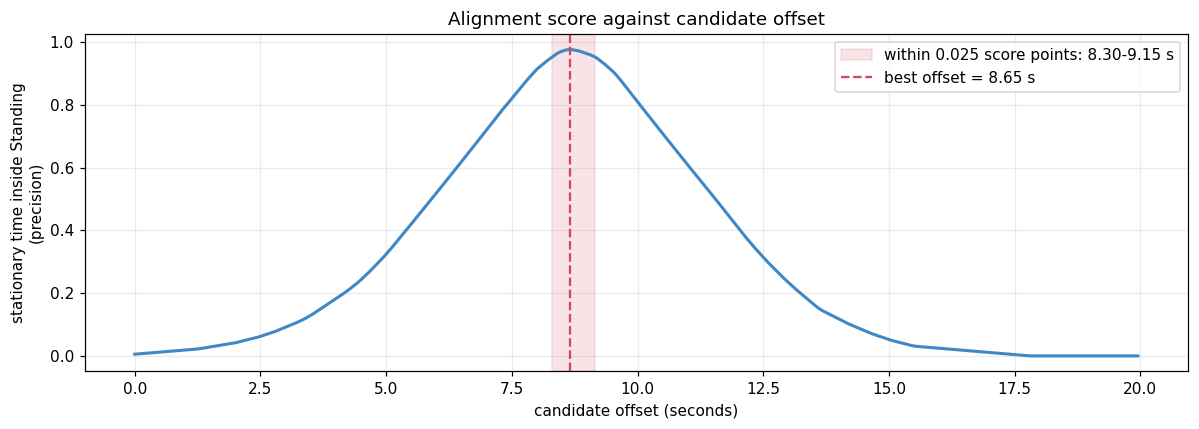

offset 8.65 s  (score stays within 0.025 points over 8.30 .. 9.15 s, a 0.85 s band)


In [ ]:
#########################################################################
# offset_score_band(candidates, scores, tolerance)
#
# Returns the (low, high) range of offsets scoring within `tolerance`
# SCORE POINTS of the peak. This describes how sharply the objective
# discriminates between offsets. It is NOT a confidence interval and
# carries no statistical coverage - there is no independent clock to
# calibrate against.
#########################################################################

def offset_score_band(candidates, scores, tolerance):
    acceptable = candidates[scores >= scores.max() - tolerance]
    return float(acceptable.min()), float(acceptable.max())


low, high = offset_score_band(candidates, scores, OFFSET_BAND_POINTS)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(candidates, scores, color=AXIS_COLOURS[2], linewidth=2)
ax.axvspan(low, high, color=AXIS_COLOURS[0], alpha=0.15,
           label=f"within {OFFSET_BAND_POINTS} score points: "
                 f"{low:.2f}-{high:.2f} s")
ax.axvline(video_start_offset, color=AXIS_COLOURS[0], linestyle="--",
           label=f"best offset = {video_start_offset:.2f} s")
ax.set_xlabel("candidate offset (seconds)")
ax.set_ylabel(f"stationary time inside {REST_LABEL}\n(precision)")
ax.set_title("Alignment score against candidate offset")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"offset {video_start_offset:.2f} s  (score stays within "
      f"{OFFSET_BAND_POINTS} points over {low:.2f} .. {high:.2f} s, "
      f"a {high - low:.2f} s band)")

The peak is unambiguous. The score climbs from near zero, tops out, and decays back to
zero by an offset of about 18 seconds, so this is a single well-defined optimum rather
than a range of equally good answers.

The band is narrower than the one-second bucket the data is quantised into, which is
the only comparison worth making: the objective cannot distinguish offsets more finely
than the evidence supports, and it does not need to, because §1.6 shows the bucket
quantisation already dominates the residual labelling error.

Two honest limits. There is no independent ground truth here. No shared clock, no
clapperboard, no second datum, so rest-period agreement is the only estimator available
and nothing external can validate it.

What makes the peak sharp is also worth stating correctly, because the obvious
explanation is wrong. It is not that only one offset puts all 14 runs inside a rest.
Every run keeps landing in some `Standing` interval across a band several seconds wide,
because the rests recur throughout the session. What distinguishes 8.65 s is the amount
of overlap, meaning how completely each detected run fits inside its rest rather than
hanging over an edge. The score is continuous in that overlap, which is why it has a
single sharp maximum instead of a plateau.

In [ ]:
#########################################################################
# alignment_report(runs, annotations, offset, video_duration)
#
# Maps each IMU stationary run into video time under the chosen offset and
# names the annotation it lands in. Runs falling outside the video are
# reported as such rather than dropped, since those are the sentinel
# brackets either side of the recording.
#########################################################################

def alignment_report(runs, annotations, offset, video_duration):
    rows = []
    for first, last in runs:
        start = first - offset
        end = last + 1 - offset
        midpoint = (start + end) / 2
        if end <= 0 or start >= video_duration:
            matched = "(outside the video)"
        else:
            hit = annotations[(annotations["start_s"] <= midpoint)
                              & (annotations["end_s"] > midpoint)]
            matched = hit["label"].iloc[0] if len(hit) else "(no annotation)"
        rows.append({"imu_first": first, "imu_last": last,
                     "video_start": round(start, 1),
                     "video_end": round(end, 1), "annotation": matched})
    return pd.DataFrame(rows)


report = alignment_report(stationary_runs, annotations, video_start_offset,
                          VIDEO_DURATION_S)
matched = (report["annotation"] == REST_LABEL).sum()
print(f"{matched} of {len(report)} stationary runs land inside a "
      f"{REST_LABEL} annotation\n")
print(report.to_string(index=False))

14 of 16 stationary runs land inside a Standing annotation

 imu_first  imu_last  video_start  video_end          annotation
         4         7         -4.6       -0.7 (outside the video)
        75        83         66.4       75.4            Standing
       148       153        139.4      145.4            Standing
       200       204        191.4      196.4            Standing
       248       252        239.4      244.4            Standing
       330       335        321.4      327.4            Standing
       380       384        371.4      376.4            Standing
       406       411        397.4      403.4            Standing
       432       434        423.4      426.4            Standing
       476       478        467.4      470.4            Standing
       547       550        538.4      542.4            Standing
       594       597        585.4      589.4            Standing
       624       628        615.4      620.4            Standing
       658       661        64

Fourteen of the sixteen runs land inside an annotated `Standing` interval, and the two
that do not are the first and last, which fall outside the video window entirely.

Those two deserve their own look, because they are the sentinel points the tutorial
describes and they confirm the offset by a second, independent route.

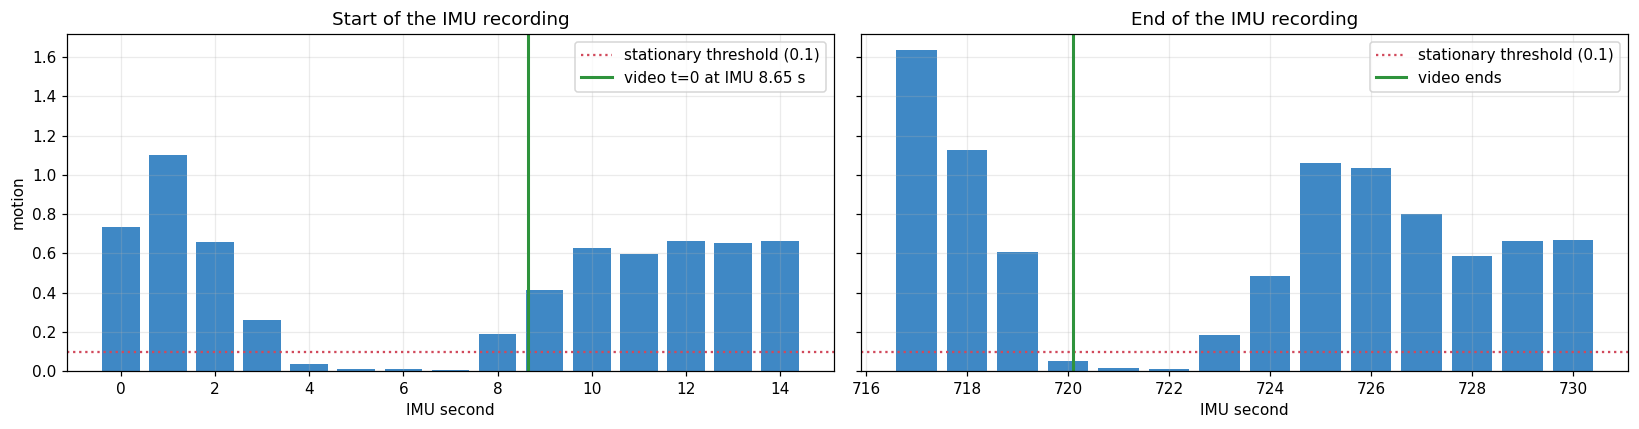

In [ ]:
head_window = per_second.loc[:14, "motion"]
tail_window = per_second.loc[per_second.index.max() - 13:, "motion"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for ax, window, title in ((axes[0], head_window, "Start of the IMU recording"),
                          (axes[1], tail_window, "End of the IMU recording")):
    ax.bar(window.index, window.to_numpy(), color=AXIS_COLOURS[2], width=0.8)
    ax.axhline(QUIET_THRESHOLD, color=AXIS_COLOURS[0], linestyle=":",
               label=f"stationary threshold ({QUIET_THRESHOLD})")
    ax.set_xlabel("IMU second")
    ax.set_title(title)

axes[0].axvline(video_start_offset, color=AXIS_COLOURS[1], linewidth=2,
                label=f"video t=0 at IMU {video_start_offset:.2f} s")
axes[1].axvline(video_start_offset + VIDEO_DURATION_S, color=AXIS_COLOURS[1],
                linewidth=2, label="video ends")
axes[0].set_ylabel("motion")
axes[0].legend(loc="upper right")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

The recording brackets the session. The logger was handled while being started
(seconds 0–3), set down and left dead still (4–7), and the session began. The
derived offset lands exactly where that stillness ends and movement resumes, which is
consistent with the first annotation being `Walking` at video time zero. The same
pattern runs in reverse at the other end: the last activity finishes, the sensor goes
still, and it is picked up again a few seconds later.

The corroboration is nearly independent, though not perfectly, and the cell below
measures it rather than claiming it. The leading bracket lies entirely before video time
zero and contributes nothing at all. The trailing bracket overhangs the end of the video
by a fraction of a second, and that sliver does enter the score. It comes to a small
fraction of one percent of the time the score is computed over, so the brackets
corroborate the offset on essentially independent evidence. "Essentially" is the honest
word there, not "entirely".

In [ ]:
outside = [(first, last) for first, last in stationary_runs
           if not (0 < (first + last + 1) / 2 - video_start_offset
                   < VIDEO_DURATION_S)]
contribution = sum(
    max(0.0, min(last + 1 - video_start_offset, VIDEO_DURATION_S)
        - max(first - video_start_offset, 0.0))
    for first, last in outside)

print(f"bracket runs (midpoint outside the video): {outside}")
print(f"contribution to the {detected:.2f} s the score was computed over: "
      f"{contribution:.2f} s ({contribution / detected:.2%})")

bracket runs (midpoint outside the video): [(np.int64(4), np.int64(7)), (np.int64(720), np.int64(722))]
contribution to the 71.10 s the score was computed over: 0.10 s (0.14%)


`VIDEO_DURATION_S` is the one number in that block imported from outside the two data
files, so `load_annotations()` validates against it directly: it refuses a duration
shorter than the last annotation's start time, and refuses any interval that comes out
non-positive. A duration wrong by a second would otherwise pass silently and quietly
shift the trim boundary, the final interval's length, and the alignment score with it.

### 1.5 Trimming to the video window

With the offset known, the IMU file can be cut down to the readings the video
actually covers. Everything before video time zero and after the video ends is
unlabelled, so it has to go.

In [ ]:
#########################################################################
# trim_to_video(readings, offset, video_duration, bucket_span)
#
# Adds a video_time column - the start of the reading's one-second bucket
# in video time - and keeps the buckets belonging to the video.
#
# A bucket is kept when its MIDPOINT falls inside the video, which is the
# same rule §1.6 uses to label it. A bucket is an interval, so the two
# boundary buckets overlap the video only partly; deciding both questions
# by the midpoint means a bucket is kept exactly when the video covers
# most of it, and no bucket is kept under one rule but labelled under
# another.
#
# bucket_bin carries that one decision to everything downstream: it is the
# whole second containing the bucket's midpoint. Bucket midpoints sit
# exactly one second apart, so no two buckets can share a bin, and a
# bucket whose start is slightly negative still lands in bin 0 rather than
# colliding with the bucket after it.
#
# Returns the trimmed DataFrame with its index reset.
#########################################################################

def trim_to_video(readings, offset, video_duration, bucket_span):
    readings = readings.copy()
    readings["video_time"] = readings["second"] - offset
    midpoint = readings["video_time"] + bucket_span / 2
    readings["bucket_bin"] = np.floor(midpoint).astype(int)
    covered = (midpoint >= 0) & (midpoint < video_duration)
    return readings.loc[covered].reset_index(drop=True)


session = trim_to_video(imu, video_start_offset, VIDEO_DURATION_S,
                        BUCKET_SPAN_S)

dropped_head = (imu["second"] - video_start_offset
                + BUCKET_SPAN_S / 2 < 0).sum()
dropped_tail = len(imu) - len(session) - dropped_head
span = f"{session['video_time'].min():.2f}..{session['video_time'].max():.2f}"
print(f"kept    {len(session):,} readings in {session['second'].nunique()} "
      f"buckets, bucket starts {span} s")
print(f"dropped {dropped_head:,} before the video and {dropped_tail:,} after "
      f"({(len(imu) - len(session)) / len(imu):.1%} of the file)")

kept    69,250 readings in 708 buckets, bucket starts 0.35..710.35 s
dropped 900 before the video and 1,092 after (2.8% of the file)


### 1.6 Labelling every reading

Each reading now carries a video time, and the annotations say which activity was
happening at any video time. Assigning labels is a matter of finding, for each
reading, the last annotation that started before it.

Tutorial 05 walks the two lists in step with a manually advanced index. A binary
search over the annotation start times does the same job in one call, and cannot
drift out of step if a reading is missing.

In [ ]:
#########################################################################
# label_readings(readings, annotations, codes, bucket_span)
#
# Assigns an activity to every reading. A reading's timestamp names a
# whole-second bucket rather than an instant, so the label is taken at the
# bucket's MIDPOINT, not its leading edge - see the discussion below for
# why that halves the error.
#
# Also flags every reading whose bucket straddles an annotation boundary,
# since those are the buckets whose label is a majority vote rather than a
# fact, and Section 2 should be able to find them.
#
# Returns the labelled DataFrame.
#########################################################################

def label_readings(readings, annotations, codes, bucket_span):
    readings = readings.copy()
    starts = annotations["start_s"].to_numpy()
    labels = annotations["label"].to_numpy()

    # Rank within the bucket would give a finer estimate, but it assumes the
    # readings are evenly spread through their own second and nothing here can
    # check that. Midpoint is the best rule the timestamps actually support.
    midpoint = readings["video_time"].to_numpy() + bucket_span / 2
    position = np.clip(np.searchsorted(starts, midpoint, side="right") - 1,
                       0, len(labels) - 1)
    readings["activity"] = labels[position]
    readings["activity_code"] = readings["activity"].map(codes)

    # A bucket [b, b+span) straddles a boundary when an annotation starts
    # strictly inside it. "left" on the upper edge excludes a start landing
    # exactly at b+span - that one opens the NEXT bucket, not this one
    # (had both edges on "right" at first, which double-counts the seam).
    bucket_start = readings["video_time"].to_numpy()
    crossed = (np.searchsorted(starts, bucket_start + bucket_span, "left")
               - np.searchsorted(starts, bucket_start, "right"))
    readings["spans_transition"] = crossed > 0
    return readings


session = label_readings(session, annotations, ACTIVITY_CODES, BUCKET_SPAN_S)

assert session["activity_code"].notna().all(), "a reading came out unlabelled"
buckets = session["video_time"].nunique()
straddling = session.loc[session["spans_transition"], "video_time"].nunique()
print(f"{straddling} of {buckets} buckets straddle an activity transition "
      f"({straddling / buckets:.1%})")
print(session[["video_time", "ax", "gz", "activity", "spans_transition"]]
      .iloc[::9000].to_string(index=False))

33 of 708 buckets straddle an activity transition (4.7%)
 video_time    ax   gz  activity  spans_transition
       0.35 -2602 -205   Walking             False
      90.35 -3620 1509   Walking             False
     183.35   414 -673   Jogging             False
     276.35 -6220  161   Jogging             False
     368.35 -1536 1297 Side-Step             False
     461.35  -452 -881   Jogging             False
     554.35  1268  754 Side-Step             False
     646.35 -1546  559   Running             False


The assertion is a guard, not a proof. `map_activity()` in Tutorial 05 returns `None`
for any label outside its hard-coded list, and a `None` propagates silently into the
target vector where it surfaces much later as a confusing error inside scikit-learn.
Failing here catches that in Section 1. What it cannot catch is a label that is
present but *wrong*, which is the subject of the next cell.

#### Labelling from the middle of the bucket, not its edge

A bucket spans one second of real time. When an annotation boundary falls inside it,
the bucket holds two activities and gets one label, so some of it is necessarily
mislabelled. What we control is *where in the bucket we read the label from*.

Reading from the leading edge is the obvious implementation, and it always returns the
outgoing activity no matter how little of the bucket that activity occupied. Its worst
case is a transition landing just after the bucket starts, because the bucket is then
almost entirely the new activity and is labelled entirely as the old one. The worst
bucket in this dataset is exactly that, a transition 0.05 s in, which mislabels 0.95 s.

Reading from the midpoint returns whichever activity held the larger share of the
bucket, with an exact 50/50 split going to the incoming one. For a bucket containing a
single transition that is the best any fixed rule can do, and it caps the error at half
a bucket. Both qualifiers are load-bearing: with two transitions inside one bucket the
midpoint can land in a short middle interval and lose the majority property altogether.
The rule is also not unbiased per class. It rounds every bucket to a whole second, and
the table below measures where that time ends up.

The two cells below measure all of that rather than asserting it.

In [ ]:
#########################################################################
# labelling_error(readings, annotations, bucket_span, video_duration)
#
# Measures how much video time each labelling rule gets wrong, by walking
# only the buckets that straddle an annotation boundary and comparing the
# label each rule assigns against what the bucket actually contained.
#
# Returns a DataFrame, one row per rule.
#########################################################################

def labelling_error(readings, annotations, bucket_span, video_duration):
    starts = annotations["start_s"].to_numpy()
    labels = annotations["label"].to_numpy()
    at = lambda t: labels[np.clip(np.searchsorted(starts, t, "right") - 1,
                                  0, len(labels) - 1)]

    rules = {"leading edge": 0.0, "midpoint": bucket_span / 2}
    totals = {name: [0.0, 0.0] for name in rules}

    for start in np.unique(readings.loc[readings["spans_transition"],
                                        "video_time"]):
        end = min(start + bucket_span, video_duration)
        edges = np.concatenate([[start], starts[(starts > start)
                                                & (starts < end)], [end]])
        pieces = [(edges[i + 1] - edges[i],
                   at((edges[i] + edges[i + 1]) / 2))
                  for i in range(len(edges) - 1)]
        for name, shift in rules.items():
            assigned = at(start + shift)
            wrong = sum(span for span, label in pieces if label != assigned)
            totals[name][0] += wrong
            totals[name][1] = max(totals[name][1], wrong)

    return pd.DataFrame(
        [{"rule": name, "seconds_mislabelled": round(total, 2),
          "worst_bucket_s": round(worst, 2),
          "share_of_video": f"{total / video_duration:.2%}"}
         for name, (total, worst) in totals.items()])


print(labelling_error(session, annotations, BUCKET_SPAN_S,
                      VIDEO_DURATION_S).to_string(index=False))

        rule  seconds_mislabelled  worst_bucket_s share_of_video
leading edge                17.15            0.95          2.41%
    midpoint                 7.58            0.48          1.07%


And the per-class cost of that rounding, which is the part a single total hides:

In [ ]:
#########################################################################
# allocation_bias(readings, annotations, bucket_span, video_duration)
#
# Compares how much time each class occupies against how much the midpoint
# rule assigns it. Both columns are measured over the RETAINED buckets
# only, so they total the retained duration rather than the video's full
# length - the point is the shift between the two, which needs both sides
# measured over the same span.
#########################################################################

def allocation_bias(readings, annotations, bucket_span, video_duration):
    starts = annotations["start_s"].to_numpy()
    labels = annotations["label"].to_numpy()
    at = lambda t: labels[np.clip(np.searchsorted(starts, t, "right") - 1,
                                  0, len(labels) - 1)]

    truth, assigned = {}, {}
    for start in np.unique(readings["video_time"]):
        end = min(start + bucket_span, video_duration)
        edges = np.concatenate([[start], starts[(starts > start)
                                                & (starts < end)], [end]])
        for i in range(len(edges) - 1):
            label = at((edges[i] + edges[i + 1]) / 2)
            truth[label] = truth.get(label, 0.0) + edges[i + 1] - edges[i]
        rounded = at(start + bucket_span / 2)
        assigned[rounded] = assigned.get(rounded, 0.0) + end - start

    frame = pd.DataFrame({"actual_in_kept_s": pd.Series(truth),
                          "assigned_s": pd.Series(assigned)}).fillna(0.0)
    frame["shift_s"] = frame["assigned_s"] - frame["actual_in_kept_s"]
    return frame.sort_values("shift_s")


# Totals come off the full-precision frame; only the printed copy rounds,
# so the shift column visibly sums to zero as conservation requires.
allocation = allocation_bias(session, annotations, BUCKET_SPAN_S,
                             VIDEO_DURATION_S)
print(allocation.round(2).to_string())
print(f"\ntotals {allocation['actual_in_kept_s'].sum():.2f} s over the "
      f"retained buckets, not the full {VIDEO_DURATION_S} s video; "
      f"shifts sum to {allocation['shift_s'].sum():+.2f}")

           actual_in_kept_s  assigned_s  shift_s
Standing              92.02        90.0    -2.02
Running              104.87       105.0     0.13
Walking              195.85       196.0     0.15
Jogging              201.20       202.0     0.80
Side-Step            114.07       115.0     0.93

totals 708.00 s over the retained buckets, not the full 711.45 s video; shifts sum to +0.00


Midpoint labelling more than halves the mislabelled time and cuts the worst single
bucket from nearly a full second to under half of one. The residue is about 1% of the
video, confined to the buckets flagged by `spans_transition`.

The allocation table shows what that total conceals. Rounding each bucket to one label
moves about two seconds of net allocation away from `Standing` and onto the activity
classes.

Resist the tidy explanation. Rounding does not inherently shrink short intervals. The
direction depends on where an interval's boundaries happen to fall relative to the
bucket grid, and in this dataset three `Standing` intervals actually gain time while ten
lose it. The net loss is measured, not predicted, and it is specific to this
recording. What generalises is only that the rounding moves time between classes at all,
which is why it is worth measuring rather than assuming it cancels out.

Be precise about what this leaves us with. Every reading carries a label, but for a
reading inside a flagged bucket that label is the bucket's majority activity, not an
observation of what that reading captured. The distinction is not pedantic: the file
records timestamps only to the second, so a per-reading ground-truth label does not
exist in the data and cannot be recovered from it. What Section 2 consumes is a window
target chosen by majority duration, which is the standard framing for windowed activity
recognition.

Tutorial 05 faces the identical quantisation but resolves it differently: it takes each
window's target from the label at the window's first sample
(`activity_timeseries[window_start_idx]`), which is the leading-edge rule measured above
at more than twice the error. The limitation is shared; the handling is not.

Nor is the residue strictly irreducible. Readings arrive in order within a bucket, so
their rank carries positional information, and interpolating on rank would relabel some
of them. The reason for not adopting it is narrower than it might look: rank
interpolation assumes readings are spread evenly through their own bucket, and nothing
in a file of whole-second timestamps can confirm or refute that. It is an unverifiable
assumption rather than a demonstrably false one. The claim here is that midpoint
labelling is the best fixed rule available, not that no better estimate could exist.

The flag is what makes this usable. Section 2 turns each bucket into one feature vector,
so the flagged buckets are precisely the training examples whose target is a vote rather
than a fact, under 5% of the dataset. Section 3 can exclude them, or keep them and check
whether its errors concentrate there. Either way the decision is visible rather than
buried, the same policy §1.8 applies to the sampling dropouts.

### 1.7 Visualising the aligned dataset

The alignment score says the two files agree. These plots are the visual check that a
reader can make independently.

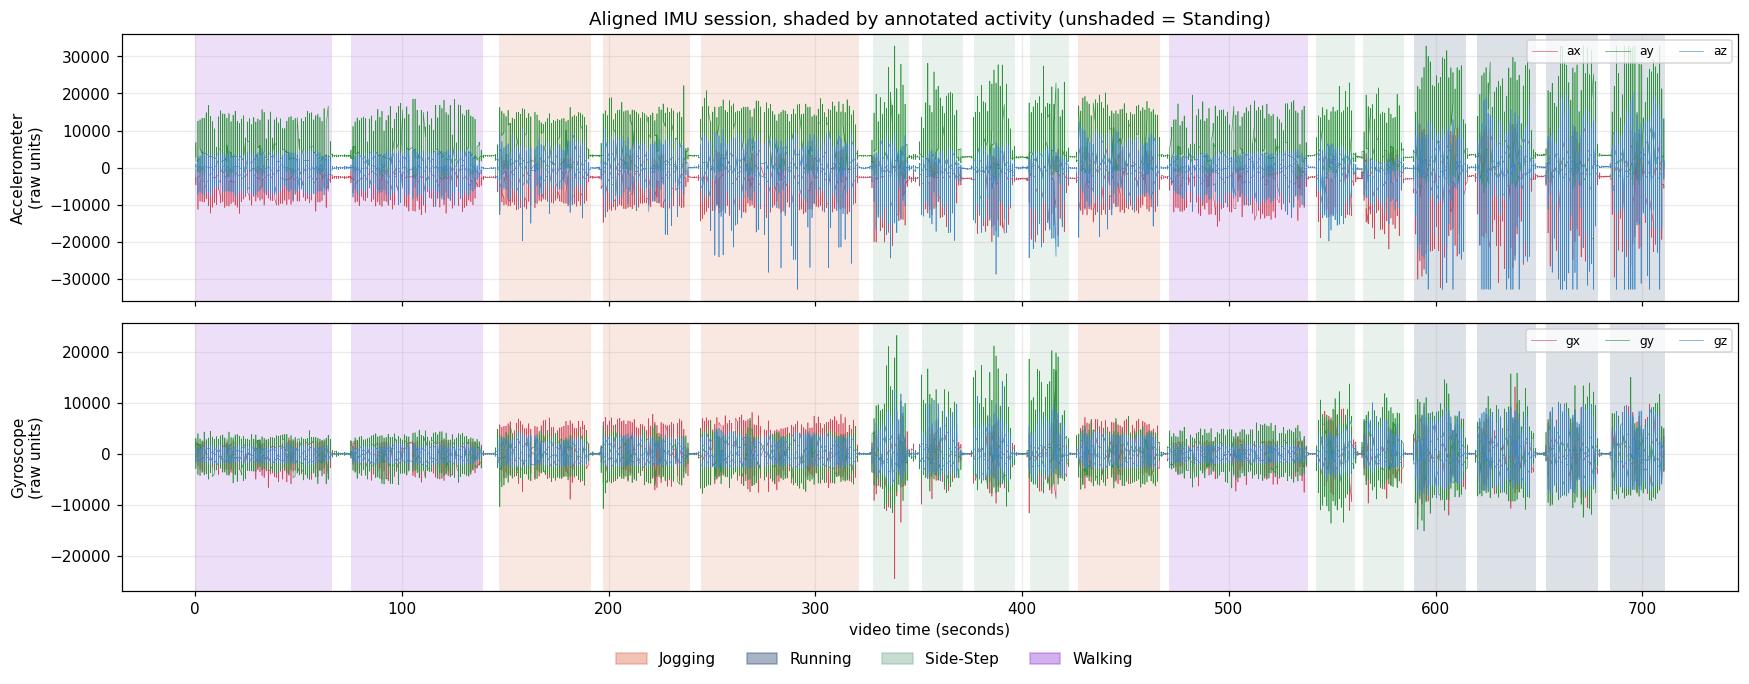

In [ ]:
#########################################################################
# shade_activities(ax, annotations, palette, skip=None)
#
# Shades each annotated interval on a video-time axis and returns the
# handles needed for a legend. Standing is skipped by the callers: it is
# 17 separate short rests, and shading each one turns the plot into
# stripes without adding anything the gaps do not already show.
#########################################################################

def shade_activities(ax, annotations, palette, skip=None):
    seen = {}
    for row in annotations.itertuples():
        if skip and row.label in skip:
            continue
        patch = ax.axvspan(row.start_s, row.end_s, alpha=0.18,
                           color=palette[row.label], linewidth=0)
        seen.setdefault(row.label, patch)
    return seen


#########################################################################
# activity_legend(fig, palette, skip, y)
#
# Adds a colour key for the shaded activity bands beneath a figure. Kept
# separate from shade_activities() so that a figure with two stacked axes
# gets one legend rather than one per axis.
#########################################################################

def activity_legend(fig, palette, skip=None, y=-0.04):
    labels = [name for name in palette if not skip or name not in skip]
    patches = [plt.Rectangle((0, 0), 1, 1, color=palette[name], alpha=0.45)
               for name in labels]
    fig.legend(patches, labels, loc="lower center", ncol=len(labels),
               bbox_to_anchor=(0.5, y), frameon=False)


ACTIVITY_PALETTE = dict(zip(ACTIVITY_LABELS,
                            ["#e07a5f", "#3d5a80", "#81b29a",
                             "#f2cc8f", "#9d4edd"]))

fig, axes = plt.subplots(2, 1, figsize=FIG_WIDE, sharex=True)
for ax, axes_group, name in ((axes[0], ACCEL_AXES, "Accelerometer"),
                             (axes[1], GYRO_AXES, "Gyroscope")):
    for column, colour in zip(axes_group, AXIS_COLOURS):
        ax.plot(session["video_time"], session[column], color=colour,
                linewidth=0.4, label=column)
    shade_activities(ax, annotations, ACTIVITY_PALETTE, skip={REST_LABEL})
    ax.set_ylabel(f"{name}\n(raw units)")
    ax.legend(loc="upper right", ncol=3, fontsize=8)

axes[1].set_xlabel("video time (seconds)")
axes[0].set_title("Aligned IMU session, shaded by annotated activity "
                  f"(unshaded = {REST_LABEL})")

activity_legend(fig, ACTIVITY_PALETTE, skip={REST_LABEL})
plt.tight_layout()
plt.show()

Every shaded block sits over a burst of signal and every unshaded gap sits over a
quiet stretch. If the offset were wrong the shading would be visibly displaced from
the activity, and at an error of a few seconds that displacement would be obvious at
this scale.

The class differences are already visible in the raw signal, which is a good sign for
Section 3: `Running` produces the widest accelerometer excursions, `Side-Step` the
most gyroscope movement relative to its accelerometer trace, and `Standing` is nearly
flat on both. §1.7 puts numbers on that impression.

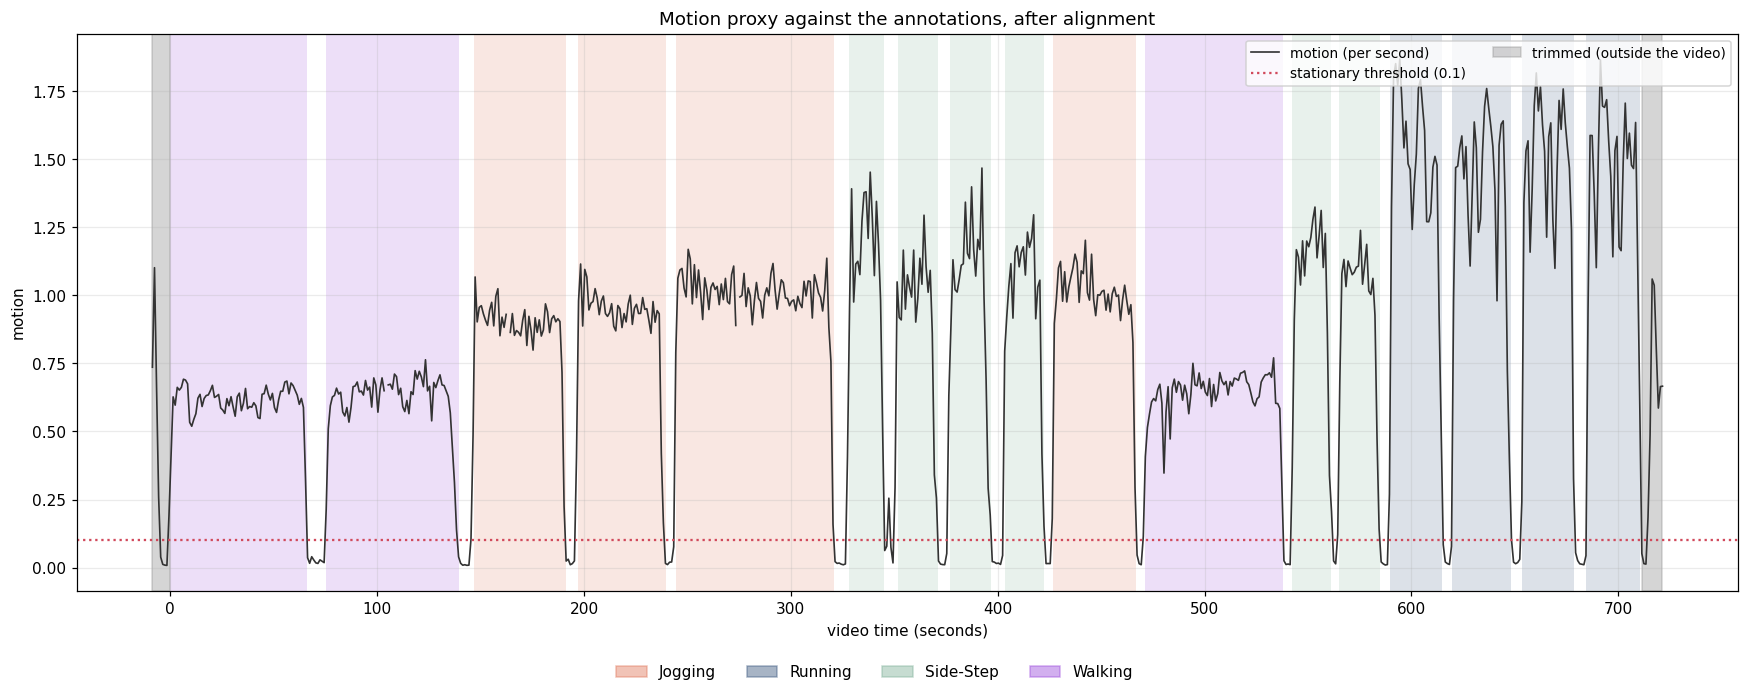

In [ ]:
fig, ax = plt.subplots(figsize=FIG_WIDE)
ax.plot(per_second.index - video_start_offset, per_second["motion"],
        color="#333333", linewidth=1.1, label="motion (per second)")
shade_activities(ax, annotations, ACTIVITY_PALETTE, skip={REST_LABEL})
ax.axhline(QUIET_THRESHOLD, color=AXIS_COLOURS[0], linestyle=":",
           label=f"stationary threshold ({QUIET_THRESHOLD})")
ax.axvspan(-video_start_offset, 0, color="#888888", alpha=0.35,
           label="trimmed (outside the video)")
ax.axvspan(VIDEO_DURATION_S,
           per_second.index.max() - video_start_offset,
           color="#888888", alpha=0.35)
ax.set_xlabel("video time (seconds)")
ax.set_ylabel("motion")
ax.set_title("Motion proxy against the annotations, after alignment")
ax.legend(loc="upper right", ncol=2, fontsize=9)

activity_legend(fig, ACTIVITY_PALETTE, skip={REST_LABEL}, y=-0.06)
plt.tight_layout()
plt.show()

This is the plot the alignment was computed from, and the two grey regions either side
are the material §1.5 removed.

Read it in the direction the numbers support. Nearly every sustained drop below the
threshold sits in an unshaded gap, where the annotations say a rest was happening. That
is the 97.7% precision, made visual. The exceptions are single seconds at the very edge of a
shaded block, where a bucket spans the moment the subject stopped and the annotation
boundary falls a fraction of a second later; those are the transition buckets from
§1.6, not detector errors.

The converse plainly does not hold: several unshaded gaps have no qualifying run under
them at all. That is the 75.4% recall, and it is the design working as intended.

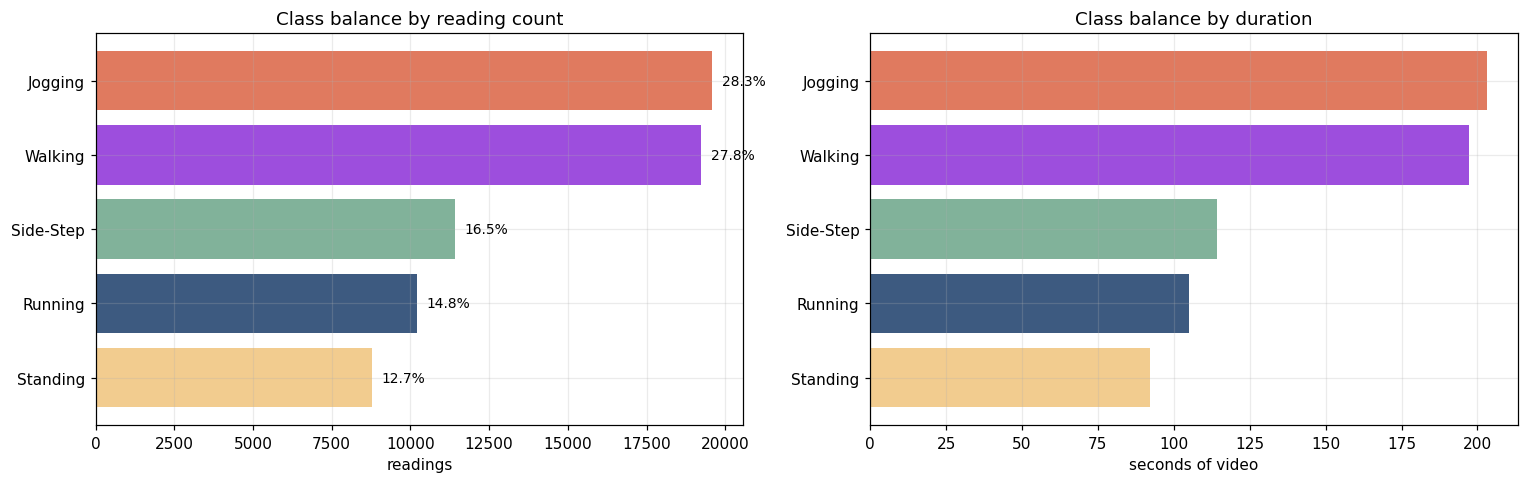

           readings  duration_s  share
activity                              
Jogging       19596     203.200  0.283
Walking       19241     197.200  0.278
Side-Step     11403     114.067  0.165
Running       10218     104.867  0.148
Standing       8792      92.117  0.127


In [ ]:
per_class = (session.groupby("activity")
             .agg(readings=("activity", "size"))
             .join(annotations.groupby("label")["duration_s"].sum())
             .sort_values("readings", ascending=False))
per_class["share"] = per_class["readings"] / per_class["readings"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colours = [ACTIVITY_PALETTE[label] for label in per_class.index]

axes[0].barh(per_class.index, per_class["readings"], color=colours)
axes[0].set_xlabel("readings")
axes[0].set_title("Class balance by reading count")
axes[0].invert_yaxis()
for position, (count, share) in enumerate(zip(per_class["readings"],
                                              per_class["share"])):
    axes[0].text(count + 300, position, f"{share:.1%}", va="center",
                 fontsize=9)

axes[1].barh(per_class.index, per_class["duration_s"], color=colours)
axes[1].set_xlabel("seconds of video")
axes[1].set_title("Class balance by duration")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(per_class.round(3).to_string())

Counting annotation rows gives the wrong picture here, and it is worth being explicit
about why. `Standing` is by far the most frequent label, occupying 17 of the 34
annotation rows, which invites the conclusion that it dominates the dataset. It does
not. Each `Standing` interval is a short rest averaging about five seconds, while the
activity bouts either side of it run for twenty to sixty seconds. Measured by how many
readings carry each label, which is the measure that matters here, `Standing` is the
smallest class in the set.

The imbalance is real but mild, roughly two to one between the largest and smallest
classes. That is a materially different situation from a dominant majority class:

* A classifier predicting the single most common class for everything would score
  about 28%, so accuracy is not meaningless here the way it would be under a heavy
  skew. It is still the wrong headline, because it says nothing about *which* classes
  a model confuses, and the per-class precision, recall and F1 the brief asks for are
  what will separate the models in Section 3.
* The split should still be stratified. With around a hundred windows in the smallest
  class after Section 2 aggregates to one-second windows, an unlucky random split can
  skew a class's representation enough to move its recall noticeably.

Section 2's windowing reduces roughly seventy thousand readings to about seven hundred
one-second windows. The proportions shift only slightly in doing so, because a window is
one vote regardless of how many readings it held, so classes sitting in thin or
truncated seconds move by a few tenths of a percent. What changes materially is the absolute
count, which is what makes the stratification point above more than tidiness.

#### Which classes should be hard

Before any modelling, the raw signal already says something about which distinctions
Section 3 will find easy and which it will not. This is worth measuring rather than
asserting, and it gives Section 3 a prior expectation to check its results against.

           accel_mean  accel_sd  gyro_mean  gyro_sd
activity                                           
Running        7920.0    6424.0     4322.0   2392.0
Side-Step      5375.0    4312.0     3373.0   2416.0
Jogging        5517.0    4274.0     2794.0   1381.0
Walking        4665.0    2393.0     2110.0    998.0
Standing       4140.0     420.0      249.0    523.0

Standing sits 8.5x below the next-lowest class on mean gyroscope magnitude


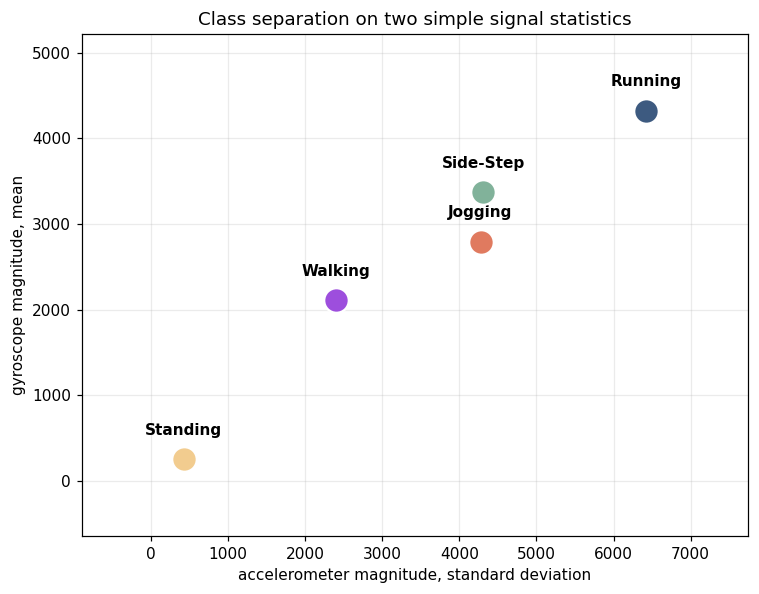

In [ ]:
separability = (session.groupby("activity")
                .agg(accel_mean=("a_mag", "mean"), accel_sd=("a_mag", "std"),
                     gyro_mean=("g_mag", "mean"), gyro_sd=("g_mag", "std"))
                .round(0)
                .sort_values("accel_sd", ascending=False))
print(separability.to_string())

quietest = separability["gyro_mean"].idxmin()
ratio = (separability["gyro_mean"].drop(quietest).min()
         / separability["gyro_mean"].min())
print(f"\n{quietest} sits {ratio:.1f}x below the next-lowest class on mean "
      f"gyroscope magnitude")

fig, ax = plt.subplots(figsize=(7, 5.5))
for label in ACTIVITY_LABELS:
    rows = separability.loc[label]
    ax.scatter(rows["accel_sd"], rows["gyro_mean"], s=260,
               color=ACTIVITY_PALETTE[label], edgecolor="white",
               linewidth=1.5, zorder=3)
    ax.annotate(label, (rows["accel_sd"], rows["gyro_mean"]),
                textcoords="offset points", xytext=(0, 16), ha="center",
                fontsize=10, fontweight="bold")
ax.set_xlabel("accelerometer magnitude, standard deviation")
ax.set_ylabel("gyroscope magnitude, mean")
ax.set_title("Class separation on two simple signal statistics")
ax.margins(0.22)
plt.tight_layout()
plt.show()

Two things follow, and Section 3 should expect both.

`Standing` should be close to trivial. Its mean gyroscope magnitude sits several times
below every other class, which is exactly what "not moving" looks like on a rotation
sensor, and a single threshold on one feature would very nearly isolate it. Any
classifier that struggles with `Standing` has something wrong with it.

The harder problem is that `Jogging` and `Side-Step` sit almost on top of each other
on accelerometer variability, and separate mainly on the gyroscope. `Running` is
distinguishable from `Jogging` in degree rather than kind, being the same gait pattern
with more force behind it. If the confusion matrices in Section 3 show errors
anywhere, these are the pairs to expect them in, and that is a prediction made from
Section 1 that Section 3 can check.

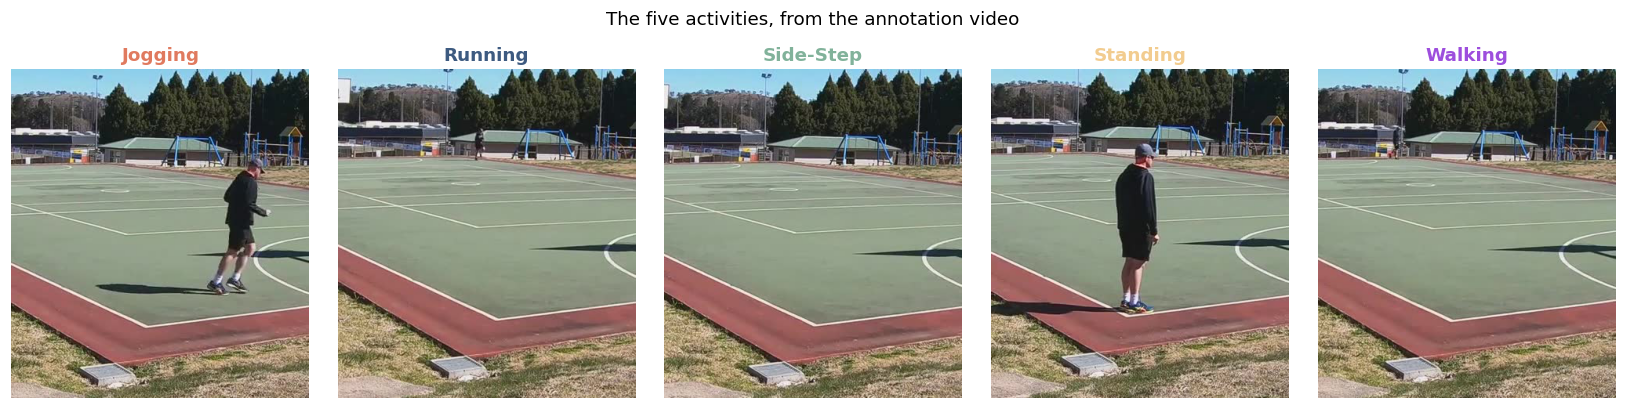

In [ ]:
#########################################################################
# show_class_frames(frame_dir, labels, palette)
#
# Displays one still per activity from the annotation video. These were
# cropped using the VoTT bounding boxes at the midpoint of each class's
# longest interval. Says so plainly when the frames are missing rather
# than skipping quietly, since the surrounding text discusses them.
#########################################################################

def show_class_frames(frame_dir, labels, palette):
    available = [label for label in labels
                 if os.path.exists(os.path.join(frame_dir, f"{label}.jpg"))]
    missing = [label for label in labels if label not in available]
    if missing:
        print(f"NOT SHOWN - no image for {missing} in {frame_dir}/")
    if not available:
        print("no class frames available; the figure below is absent")
        return

    fig, axes = plt.subplots(1, len(available),
                             figsize=(3.0 * len(available), 3.6))
    for ax, label in zip(np.atleast_1d(axes), available):
        ax.imshow(plt.imread(os.path.join(frame_dir, f"{label}.jpg")))
        ax.set_title(label, color=palette[label], fontweight="bold")
        ax.axis("off")
    fig.suptitle("The five activities, from the annotation video", y=1.02)
    plt.tight_layout()
    plt.show()


show_class_frames(FRAME_DIR, ACTIVITY_LABELS, ACTIVITY_PALETTE)

These stills are what the classes physically are, taken from the video the annotations
were made against. They also confirm the annotation file parses correctly: the crop
coordinates come from the same rows as the labels, so a frame showing a person
standing still under a `Standing` label means the row was read the way it was meant to
be.

### 1.8 Data quality

The brief notes that the sampling rate "can vary slightly due to the use of the SD
card". It varies more than slightly, and Section 2 needs to know by how much, because
every feature it computes is an average over one second of readings.

In [ ]:
#########################################################################
# second_quality(readings, all_readings, offset, nominal_rate, thin_ratio,
#                bucket_span, video_duration)
#
# Counts readings per second of video and flags the seconds holding too
# few readings to average over. Two distinct ways a bin can be empty are
# kept apart, and both are decided by replaying the trim rule against the
# untrimmed readings rather than by guessing from where the kept rows end:
#
#   missing           - the sensor logged nothing for that second
#   boundary_excluded - a bucket existed but the midpoint rule dropped it
#
# The index spans every whole second the video reaches, so neither kind
# can hide by simply not appearing.
#
# Returns (per-second DataFrame, summary dict).
#########################################################################

def second_quality(readings, all_readings, offset, nominal_rate, thin_ratio,
                   bucket_span, video_duration):
    counts = readings["bucket_bin"].value_counts().sort_index()

    # One bin per whole second the video reaches into, so a second excluded
    # at the boundary is visible rather than merely absent. ceil, not
    # int+1: a video of exactly 3.0 s has bins 0, 1, 2 and no bin 3.
    bins = pd.RangeIndex(0, math.ceil(video_duration), name="video_second")
    quality = counts.reindex(bins, fill_value=0).to_frame("samples")

    # Replay the trim rule against the UNTRIMMED buckets, so the two ways a
    # bin can be empty are decided by what actually happened rather than
    # inferred from where the retained rows happen to stop. The predicate
    # here is the midpoint rule and nothing else - adding a leading-edge
    # prefilter would drop a bucket that trim_to_video() keeps.
    midpoints = (np.unique(all_readings["second"].to_numpy()) - offset
                 + bucket_span / 2)
    logged = set(np.floor(midpoints).astype(int))
    survived = set(np.floor(midpoints[(midpoints >= 0)
                                      & (midpoints < video_duration)])
                   .astype(int))

    threshold = nominal_rate * thin_ratio
    quality["missing"] = [index not in logged for index in bins]
    quality["boundary_excluded"] = [index in logged and index not in survived
                                    for index in bins]
    quality["thin"] = ((quality["samples"] > 0)
                       & (quality["samples"] < threshold))

    present = quality.loc[quality["samples"] > 0, "samples"]
    summary = {"seconds": len(quality),
               "missing": int(quality["missing"].sum()),
               "boundary": int(quality["boundary_excluded"].sum()),
               "thin": int(quality["thin"].sum()),
               "fewest": int(present.min()), "median": int(present.median()),
               "most": int(present.max()), "threshold": threshold}
    return quality, summary


quality, quality_summary = second_quality(
    session, imu, video_start_offset, NOMINAL_RATE_HZ, THIN_SECOND_RATIO,
    BUCKET_SPAN_S, VIDEO_DURATION_S)

# Carry the per-second counts onto the rows themselves, so the exported CSV
# is self-describing rather than needing the quality table alongside it.
session["bucket_samples"] = session["bucket_bin"].map(quality["samples"])
session["bucket_thin"] = session["bucket_bin"].map(quality["thin"])

last_bin_s = VIDEO_DURATION_S % 1 or float(BUCKET_SPAN_S)
print(f"{quality_summary['seconds']} indexed video-second bins "
      f"(the last covers {last_bin_s:.2f} s of video)")
print(f"  sensor dropouts  : {quality_summary['missing']}")
print(f"  trimmed at the boundary : {quality_summary['boundary']}")
print(f"  under {quality_summary['threshold']:.0f} readings : "
      f"{quality_summary['thin']}")
print(f"  readings/second  : {quality_summary['fewest']} lowest, "
      f"{quality_summary['median']} median, {quality_summary['most']} highest")

flagged = quality[quality["missing"] | quality["thin"]
                  | quality["boundary_excluded"]]
if len(flagged):
    print(f"\naffected seconds:\n{flagged.to_string()}")

712 indexed video-second bins (the last covers 0.45 s of video)
  sensor dropouts  : 3
  trimmed at the boundary : 1
  under 50 readings : 6
  readings/second  : 9 lowest, 100 median, 200 highest

affected seconds:
              samples  missing  boundary_excluded   thin
video_second                                            
104                 0     True              False  False
163                 0     True              False  False
232                 9    False              False   True
250                42    False              False   True
274                 0     True              False  False
317                49    False              False   True
442                12    False              False   True
480                36    False              False   True
700                43    False              False   True
711                 0    False               True  False


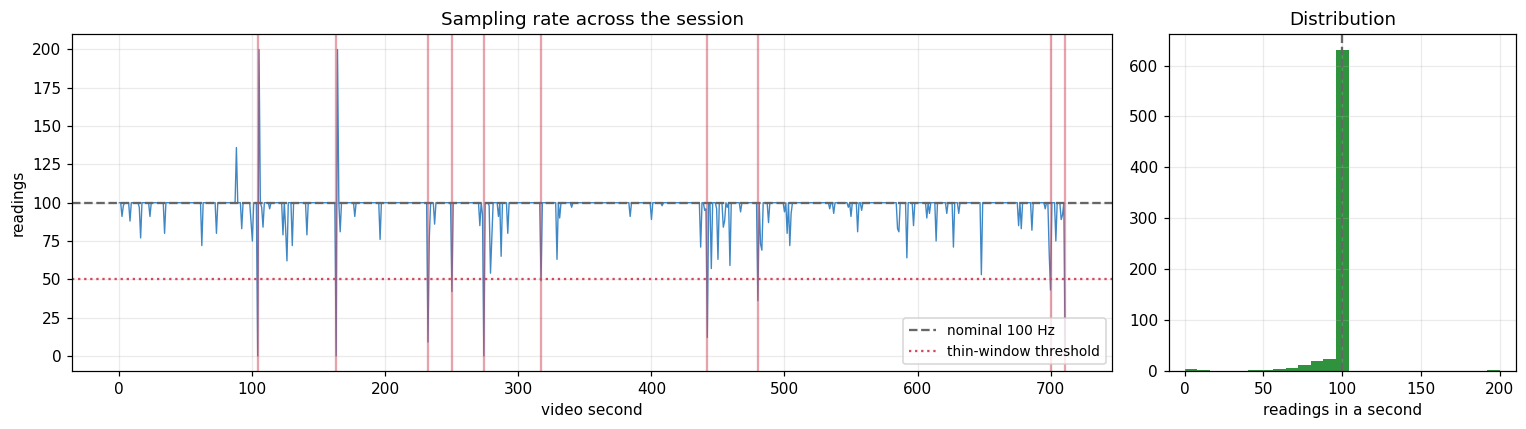

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         gridspec_kw={"width_ratios": [3, 1]})

axes[0].plot(quality.index, quality["samples"], color=AXIS_COLOURS[2],
             linewidth=0.9)
axes[0].axhline(NOMINAL_RATE_HZ, color="#666666", linestyle="--",
                label=f"nominal {NOMINAL_RATE_HZ} Hz")
axes[0].axhline(quality_summary["threshold"], color=AXIS_COLOURS[0],
                linestyle=":", label="thin-window threshold")
for second in quality.index[quality["missing"] | quality["thin"]
                            | quality["boundary_excluded"]]:
    axes[0].axvline(second, color=AXIS_COLOURS[0], alpha=0.5, linewidth=1.5)
axes[0].set_xlabel("video second")
axes[0].set_ylabel("readings")
axes[0].set_title("Sampling rate across the session")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].hist(quality["samples"], bins=25, color=AXIS_COLOURS[1])
axes[1].axvline(NOMINAL_RATE_HZ, color="#666666", linestyle="--")
axes[1].set_xlabel("readings in a second")
axes[1].set_title("Distribution")

plt.tight_layout()
plt.show()

#### The policy, and why it is a column rather than a filter

The rate is mostly stable
around 100 Hz with occasional dropouts, including a handful of seconds holding barely
a tenth of the expected readings and a few holding none at all.

Tutorial 05 handles its own missing seconds with a literal test, `if t == 60 or
t == 61: continue`, which works on that dataset and silently does the wrong thing on
any other. This pipeline instead carries a `samples` count per second through to
Section 2, which leaves the decision where the evidence for it is:

* a second with no readings cannot produce a feature window and is skipped
  automatically, without needing to be named;
* a thin second still produces a window, but a mean over a dozen readings is a noisier
  estimate than a mean over a hundred, and Section 2 can drop them or
  down-weight them with the count in hand.

Dropping them here instead would throw away the information needed to make that
choice, and would hide a real property of the data from the write-up.

### 1.9 What Section 1 hands to Section 2

`session` is the deliverable: one row per IMU reading, inside the video window,
carrying a video timestamp and an activity label.

| Column | Meaning |
|---|---|
| `timestamp` | original Unix epoch second from the IMU file |
| `second` | whole seconds since the first reading in the file |
| `video_time` | start of the reading's one-second bucket, in video time |
| `bucket_bin` | the whole video-second holding that bucket's midpoint; the single index shared by `window_bounds()`, the quality table and the trim |
| `ax`, `ay`, `az` | accelerometer, raw signed units |
| `gx`, `gy`, `gz` | gyroscope, raw signed units |
| `a_mag`, `g_mag` | vector magnitudes, precomputed |
| `activity` | label string |
| `activity_code` | integer target for the classifiers |
| `spans_transition` | the reading's bucket straddles an activity boundary, so its label is a majority vote rather than a fact (§1.6) |
| `bucket_samples` | how many readings that whole second held (100 is nominal) |
| `bucket_thin` | that second holds too few readings to average over confidently (§1.8) |

The last three columns carry the row-level caveats on the rows themselves, so nothing
about an individual reading has to be re-derived.

A row-based CSV structurally cannot carry a second with no readings: with no rows, it is
absent rather than flagged. Four bin indices are absent from the windows, for two
different reasons. Three are sensor dropouts inside the session (104, 163, 274), and one
was trimmed at the closing boundary (711, a partial video-second whose bucket the video
covered for only 0.10 s).

So the session CSV is self-contained for row-level quality and no further. The bin
domain is exported beside it as `data/a3_session_quality.csv`, one row per indexed
video-second with the `missing`, `boundary_excluded` and `thin` flags, so a consumer
holding only the two files can still reconstruct which indices are absent and why.

Either way, prefer `window_bounds()` over `range()`: it iterates the seconds actually
present, so an absent one is skipped by construction rather than needing to be noticed.

Alongside the frame: `annotations` (intervals in video time), `quality` (one row per
indexed video-second bin, so both kinds of absence stay visible, with `missing` and
`boundary_excluded` telling them apart), and `ACTIVITY_PALETTE` so a class keeps the
same colour in every figure in the portfolio.

`ACTIVITY_LABELS` and `ACTIVITY_CODES` carry the label-to-integer mapping. It is
alphabetical, derived from the file rather than typed out, so it does not match the
order in Tutorial 05. Section 3 should pass `ACTIVITY_LABELS` to
`ConfusionMatrixDisplay(display_labels=...)` rather than writing a list by hand, or
the axes of the confusion matrices will be labelled with the wrong class names while
still looking perfectly plausible.

In [ ]:
#########################################################################
# window_bounds(readings)
#
# Yields (bin, first_index, last_index) for each bin holding readings,
# which is the iteration Section 2 needs for its moving window. Grouping
# on bucket_bin rather than re-deriving a second from video_time keeps
# this in step with the trim and the quality table by construction. Bins
# with no readings are absent from the sequence rather than needing to be
# tested for by number.
#
# Exactly one bin per window, deliberately. There is no window_size here:
# the timestamps quantise to one second, so a shorter window cannot be
# cut, and a longer one is a concatenation of consecutive bins that
# Section 2 should build (and decide the overlap policy for) itself.
#########################################################################

def window_bounds(readings):
    bins = readings["bucket_bin"].to_numpy()
    for current in np.unique(bins):
        positions = np.flatnonzero(bins == current)
        if positions.size:
            yield int(current), int(positions[0]), int(positions[-1] + 1)


windows = list(window_bounds(session))
print(f"{len(windows)} one-second windows available to Section 2")
print(f"first: {windows[0]}   last: {windows[-1]}")

session.to_csv(os.path.join(DATA_DIR, "a3_labelled_session.csv"), index=False)
quality.to_csv(os.path.join(DATA_DIR, "a3_session_quality.csv"))
print(f"\nwrote {DATA_DIR}/a3_labelled_session.csv "
      f"({len(session):,} rows x {session.shape[1]} columns)")
print(f"wrote {DATA_DIR}/a3_session_quality.csv "
      f"({len(quality)} bins x {quality.shape[1]} columns)")

708 one-second windows available to Section 2
first: (0, 0, 100)   last: (710, 69150, 69250)

wrote data/a3_labelled_session.csv (69,250 rows x 17 columns)
wrote data/a3_session_quality.csv (712 bins x 4 columns)



wrote data/a3_labelled_session.csv (69,250 rows x 17 columns)
wrote data/a3_session_quality.csv (712 bins x 4 columns)


`window_bounds()` exists so that Section 2 does not have to re-derive the window
boundaries or work around the gaps. It skips absent seconds by construction, which is
the generic version of the hard-coded skip in the tutorial.

The labelled session is also written to `data/a3_labelled_session.csv`, so Section 2
can be developed and re-run without repeating the alignment each time.

#### Section 1 summary

The offset between the IMU clock and the video clock was
derived rather than estimated by eye, by finding the alignment that best reconciles two
views of the same rest periods, one taken from the sensor and one from the annotations.
It also agrees with the stationary brackets at either end of the recording, which
contribute 0.14% of the score and so corroborate it on very nearly independent evidence
(§1.4 measures exactly how nearly). The IMU file was trimmed to the buckets the video
covers, every remaining reading was labelled, and the result was checked visually
against the annotations.

Three things are carried forward as data rather than quietly repaired, because each
changes what Sections 2 and 3 should do: the class imbalance, the sampling dropouts, and
the transition buckets whose target is a majority vote rather than an observation.

---

# Section 2. Feature engineering

*Author: Davina Prasad*

> Consumes `session`, `windows` / `window_bounds()`, and `quality` from Section 1.
> Produces the feature matrix and target vector for Section 3.

Moving-window features over one-second windows, across both the accelerometer and the
gyroscope: mean, minimum and maximum per axis, Signal Magnitude Area, and Average
Intensity.

$$SMA = \frac{1}{T}\left(\sum_{t=1}^{T}|a_x(t)| + \sum_{t=1}^{T}|a_y(t)|
+ \sum_{t=1}^{T}|a_z(t)|\right)$$

$$AI = \frac{1}{T}\sum_{t=1}^{T} \sqrt{a_x(t)^2 + a_y(t)^2 + a_z(t)^2}$$

### 2.1 Which features, and why

**Accelerometer features (x, y, z axes)**
- Mean, minimum and maximum per axis (9 features)
- Signal Magnitude Area (SMA), the summed absolute value across axes
- Average Intensity (AI), the mean magnitude across all samples in the window

**Gyroscope features (x, y, z axes)**
- Mean, minimum and maximum per axis (9 features)
- Signal Magnitude Area
- Average Intensity

Twenty-two features in total, eleven per sensor. They capture both the magnitude and
the variability of motion, which is what separates activities like walking, jogging and
running from each other.

**Window selection.** 702 of the 708 windows Section 1 provides are used. Six are dropped
for holding fewer than 50 readings, which is too thin to average over; they are exactly
the six Section 1 flagged as `bucket_thin`. The 33 windows flagged `spans_transition` are
kept. Their label is a majority-duration vote rather than an observation, but discarding
them would remove precisely the moments where one activity becomes another, and those are
the windows a classifier is most likely to confuse. They are better kept and accounted for
in Section 3's error analysis than quietly removed here.

**A note on the AI formula.** The assignment brief and Tutorial 05 do not define Average
Intensity the same way. The brief places the square root inside the sum, giving the mean
per-sample magnitude; the tutorial's code computes `sqrt(sum)/T`, which takes the root of
the total instead. The implementation below follows the brief. The two correlate at
r = 0.96 and separate the classes about equally well (ANOVA F of 525 against 486), so the
choice changes the scale of the feature rather than its usefulness.

In [ ]:
# Helper functions for feature extraction

def calculate_sma(data_array):
    """
    Calculate Signal Magnitude Area.
    
    Args:
        data_array: array of shape (n_samples, 3) for x, y, z axes
    
    Returns:
        float: SMA value
    """
    T = len(data_array)
    sma = (1/T) * (np.sum(np.abs(data_array[:, 0])) + 
                   np.sum(np.abs(data_array[:, 1])) + 
                   np.sum(np.abs(data_array[:, 2])))
    return sma


def calculate_ai(data_array):
    """
    Calculate Average Intensity.
    
    Args:
        data_array: array of shape (n_samples, 3) for x, y, z axes
    
    Returns:
        float: AI value
    """
    T = len(data_array)
    magnitudes = np.sqrt(data_array[:, 0]**2 + 
                         data_array[:, 1]**2 + 
                         data_array[:, 2]**2)
    ai = np.mean(magnitudes)
    return ai


In [ ]:
# Extract features from all windows

def extract_window_features(window_data):
    """
    Extract all 22 features from a single one-second window.
    
    Args:
        window_data: dataframe slice for one window
    
    Returns:
        dict: feature names and values
    """
    accel = window_data[['ax', 'ay', 'az']].values
    gyro = window_data[['gx', 'gy', 'gz']].values
    
    features = {
        # Accelerometer features
        'accel_x_mean': np.mean(accel[:, 0]),
        'accel_x_min': np.min(accel[:, 0]),
        'accel_x_max': np.max(accel[:, 0]),
        'accel_y_mean': np.mean(accel[:, 1]),
        'accel_y_min': np.min(accel[:, 1]),
        'accel_y_max': np.max(accel[:, 1]),
        'accel_z_mean': np.mean(accel[:, 2]),
        'accel_z_min': np.min(accel[:, 2]),
        'accel_z_max': np.max(accel[:, 2]),
        'accel_sma': calculate_sma(accel),
        'accel_ai': calculate_ai(accel),
        
        # Gyroscope features
        'gyro_x_mean': np.mean(gyro[:, 0]),
        'gyro_x_min': np.min(gyro[:, 0]),
        'gyro_x_max': np.max(gyro[:, 0]),
        'gyro_y_mean': np.mean(gyro[:, 1]),
        'gyro_y_min': np.min(gyro[:, 1]),
        'gyro_y_max': np.max(gyro[:, 1]),
        'gyro_z_mean': np.mean(gyro[:, 2]),
        'gyro_z_min': np.min(gyro[:, 2]),
        'gyro_z_max': np.max(gyro[:, 2]),
        'gyro_sma': calculate_sma(gyro),
        'gyro_ai': calculate_ai(gyro),
    }
    
    return features


# Main loop: iterate through windows
features_list = []
dropped_windows = []

for bucket_bin, start_idx, end_idx in window_bounds(session):
    window_data = session.iloc[start_idx:end_idx]
    n_samples = len(window_data)
    
    # Drop windows with fewer than 50 samples
    if n_samples < 50:
        dropped_windows.append({
            'bucket_bin': bucket_bin,
            'n_samples': n_samples,
            'reason': 'too few samples'
        })
        continue
    
    # Extract features
    features = extract_window_features(window_data)
    
    # Add metadata for traceability
    features['bucket_bin'] = bucket_bin
    features['activity'] = window_data['activity'].iloc[0]
    features['activity_code'] = window_data['activity_code'].iloc[0]
    features['bucket_samples'] = n_samples
    
    features_list.append(features)

# Create feature dataframe
features_df = pd.DataFrame(features_list)

print(f"✓ Created feature matrix: {features_df.shape}")
print(f"✓ Windows processed: {len(features_df)}")
print(f"✓ Windows dropped: {len(dropped_windows)}")

✓ Created feature matrix: (702, 26)
✓ Windows processed: 702
✓ Windows dropped: 6


In [ ]:
# Document which windows were dropped and why

print("=" * 60)
print("WINDOWS DROPPED FROM FEATURE SET")
print("=" * 60)

if dropped_windows:
    for drop in dropped_windows:
        print(f"Window {drop['bucket_bin']:3d}: {drop['n_samples']:2d} samples - {drop['reason']}")
else:
    print("No windows dropped.")

print(f"\nTotal dropped: {len(dropped_windows)} out of 708")
print(f"Retention rate: {(702/708)*100:.1f}%")

WINDOWS DROPPED FROM FEATURE SET
Window 232:  9 samples - too few samples
Window 250: 42 samples - too few samples
Window 317: 49 samples - too few samples
Window 442: 12 samples - too few samples
Window 480: 36 samples - too few samples
Window 700: 43 samples - too few samples

Total dropped: 6 out of 708
Retention rate: 99.2%


In [ ]:
# Summary of features and activities

print("\n" + "=" * 60)
print("FEATURE MATRIX SUMMARY")
print("=" * 60)

print(f"\nShape: {features_df.shape}")
print(f"Rows (windows): {features_df.shape[0]}")
print(f"Columns: {features_df.shape[1]}")

print("\nActivity distribution:")
print(features_df['activity'].value_counts().sort_index())

print("\nFeature columns (in order):")
feature_cols = [col for col in features_df.columns 
                if col not in ['bucket_bin', 'activity', 'activity_code', 'bucket_samples']]
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")


FEATURE MATRIX SUMMARY

Shape: (702, 26)
Rows (windows): 702
Columns: 26

Activity distribution:
activity
Jogging      198
Running      104
Side-Step    115
Standing      90
Walking      195
Name: count, dtype: int64

Feature columns (in order):
   1. accel_x_mean
   2. accel_x_min
   3. accel_x_max
   4. accel_y_mean
   5. accel_y_min
   6. accel_y_max
   7. accel_z_mean
   8. accel_z_min
   9. accel_z_max
  10. accel_sma
  11. accel_ai
  12. gyro_x_mean
  13. gyro_x_min
  14. gyro_x_max
  15. gyro_y_mean
  16. gyro_y_min
  17. gyro_y_max
  18. gyro_z_mean
  19. gyro_z_min
  20. gyro_z_max
  21. gyro_sma
  22. gyro_ai


In [ ]:
# Statistical summary of features

print("\n" + "=" * 60)
print("FEATURE STATISTICS")
print("=" * 60)

feature_cols = [col for col in features_df.columns 
                if col not in ['bucket_bin', 'activity', 'activity_code', 'bucket_samples']]

print(features_df[feature_cols].describe().round(2))


FEATURE STATISTICS
       accel_x_mean  accel_x_min  accel_x_max  accel_y_mean  accel_y_min  \
count        702.00       702.00       702.00        702.00       702.00   
mean       -2650.59    -11214.08      2195.51       3368.07     -1049.19   
std          366.25      5556.50      3449.26        338.40      2050.56   
min        -3942.91    -32298.00     -2894.00       2579.08     -9268.00   
25%        -2838.24    -12954.50      -316.00       3139.66     -2179.50   
50%        -2685.90    -10655.00      1888.00       3273.07     -1171.00   
75%        -2516.11     -8745.00      3892.00       3619.94      -351.50   
max        -1121.46     -2290.00     12380.00       4651.42      3422.00   

       accel_y_max  accel_z_mean  accel_z_min  accel_z_max  accel_sma  ...  \
count       702.00        702.00       702.00       702.00     702.00  ...   
mean      14681.67       -315.76     -9773.79      5219.88    8147.92  ...   
std        6668.34        348.67      7794.95      3755.00   

### 2.2 Feature distributions and correlations

How the features vary across activities, and how far they duplicate each other.

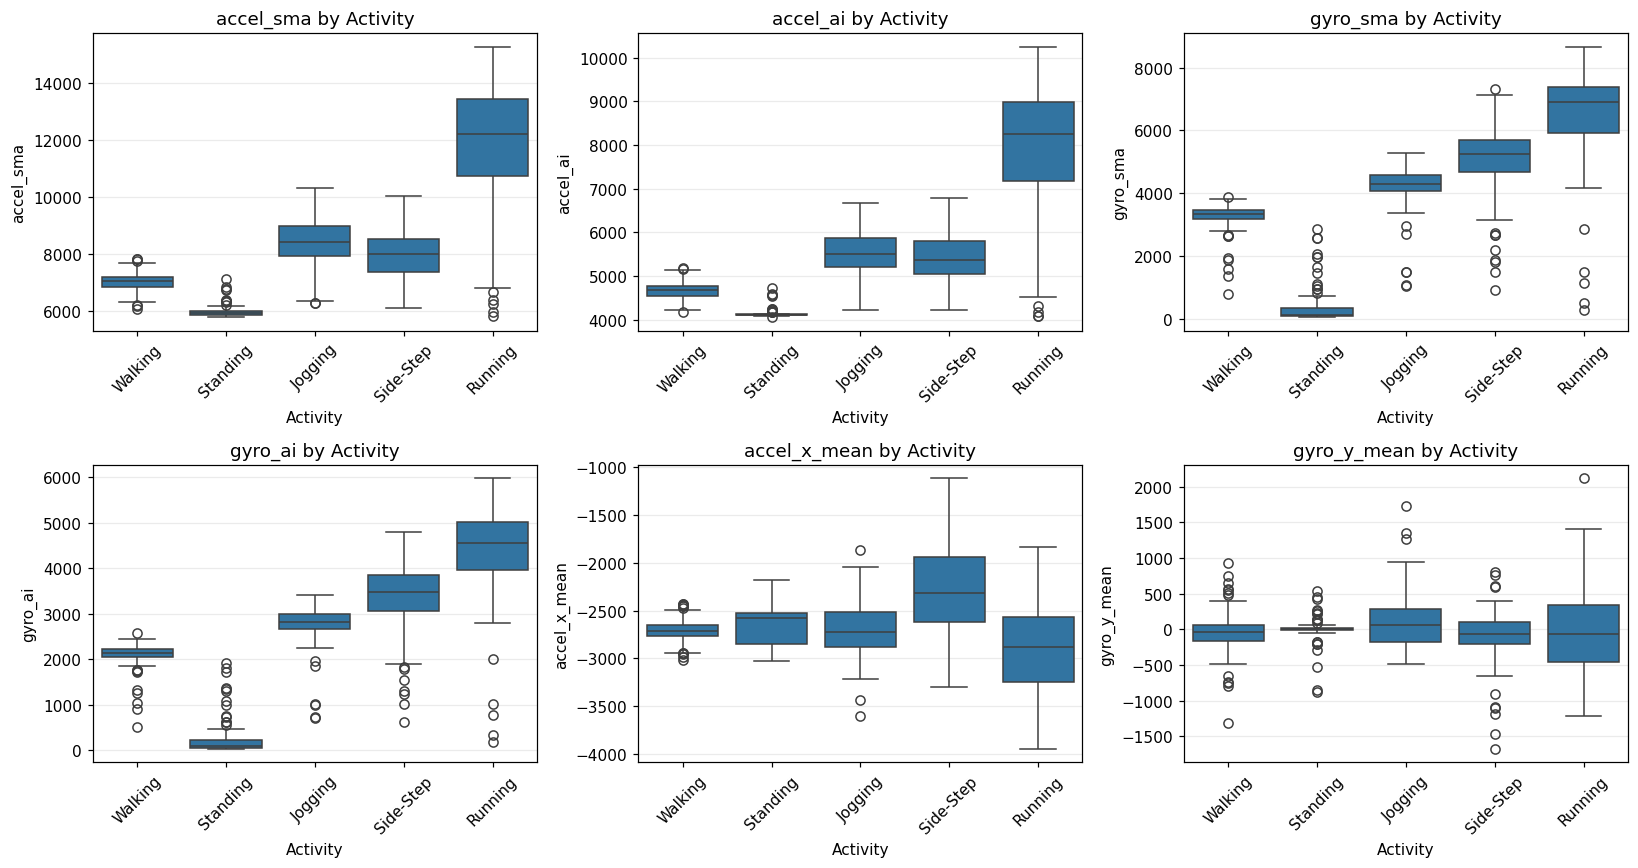

✓ Feature distributions plotted


In [ ]:
# Visualise feature distributions by activity

import matplotlib.pyplot as plt
import seaborn as sns

# Select a few key features to visualize
key_features = ['accel_sma', 'accel_ai', 'gyro_sma', 'gyro_ai', 
                'accel_x_mean', 'gyro_y_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    ax = axes[idx]
    sns.boxplot(data=features_df, x='activity', y=feature, ax=ax)
    ax.set_title(f'{feature} by Activity')
    ax.set_xlabel('Activity')
    ax.set_ylabel(feature)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print("✓ Feature distributions plotted")

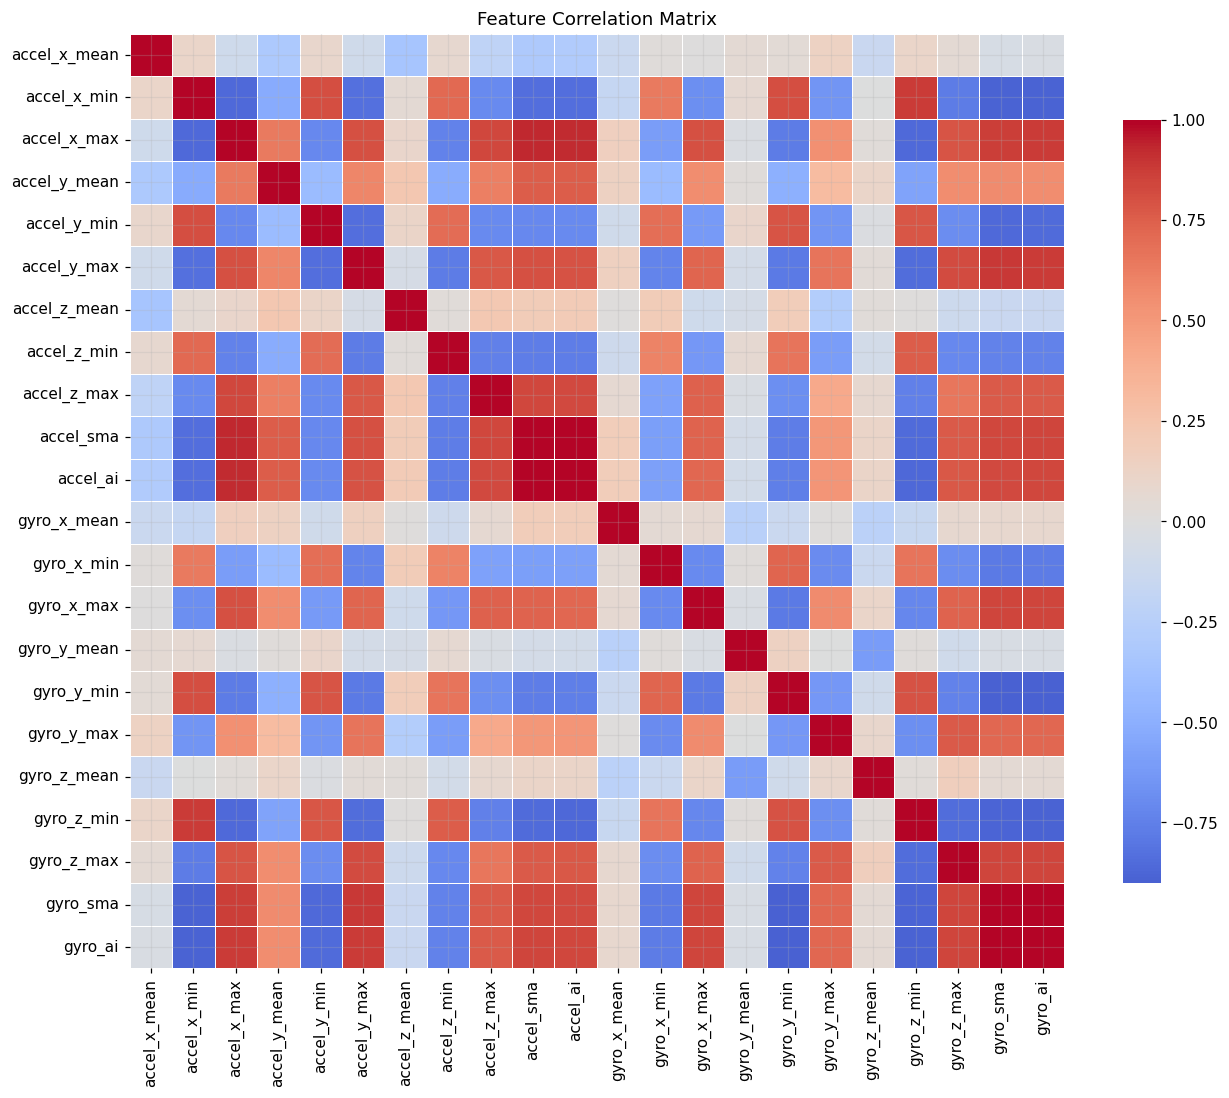

✓ Correlation heatmap plotted


In [ ]:
# Correlation between features

feature_cols = [col for col in features_df.columns 
                if col not in ['bucket_bin', 'activity', 'activity_code', 'bucket_samples']]

correlation_matrix = features_df[feature_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap plotted")

In [ ]:
# HANDOFF NOTES ASH

print("\n" + "=" * 60)
print("HANDOFF NOTES FOR SECTION 3")
print("=" * 60)

# Feature names in column order (for decision tree plots)
feature_names = [col for col in features_df.columns 
                 if col not in ['bucket_bin', 'activity', 'activity_code', 'bucket_samples']]

print("\nFeature names (in column order):")
print(feature_names)

print("\nDropped windows:")
print(f"  Total: {len(dropped_windows)}")
if dropped_windows:
    for drop in dropped_windows:
        print(f"    Bin {drop['bucket_bin']}: {drop['n_samples']} samples")

print("\nTarget variable:")
print(f"  Column: 'activity_code'")
print(f"  Classes: {sorted(features_df['activity_code'].unique())}")
print(f"  Distribution:")
for code in sorted(features_df['activity_code'].unique()):
    count = (features_df['activity_code'] == code).sum()
    activity = features_df[features_df['activity_code'] == code]['activity'].iloc[0]
    print(f"    {code}: {activity:12s} ({count:3d} windows)")

print("\nTraceability:")
print(f"  bucket_bin column preserved for video frame tracing")
print(f"  bucket_samples column shows sample count per window")



HANDOFF NOTES FOR SECTION 3

Feature names (in column order):
['accel_x_mean', 'accel_x_min', 'accel_x_max', 'accel_y_mean', 'accel_y_min', 'accel_y_max', 'accel_z_mean', 'accel_z_min', 'accel_z_max', 'accel_sma', 'accel_ai', 'gyro_x_mean', 'gyro_x_min', 'gyro_x_max', 'gyro_y_mean', 'gyro_y_min', 'gyro_y_max', 'gyro_z_mean', 'gyro_z_min', 'gyro_z_max', 'gyro_sma', 'gyro_ai']

Dropped windows:
  Total: 6
    Bin 232: 9 samples
    Bin 250: 42 samples
    Bin 317: 49 samples
    Bin 442: 12 samples
    Bin 480: 36 samples
    Bin 700: 43 samples

Target variable:
  Column: 'activity_code'
  Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Distribution:
    0: Jogging      (198 windows)
    1: Running      (104 windows)
    2: Side-Step    (115 windows)
    3: Standing     ( 90 windows)
    4: Walking      (195 windows)

Traceability:
  bucket_bin column preserved for video frame tracing
  bucket_samples column shows sample count per window

✓ Ready for Sectio

In [ ]:
# Save features for Section 3

import json

FEATURE_FILE = os.path.join(DATA_DIR, "a3_features.csv")
FEATURE_NAMES_FILE = os.path.join(DATA_DIR, "a3_feature_names.json")

features_df.to_csv(FEATURE_FILE, index=False)
print(f"wrote {FEATURE_FILE} ({len(features_df)} rows x {features_df.shape[1]} columns)")

# The 22 feature columns, in the order Section 3 must use. bucket_bin, activity,
# activity_code and bucket_samples are metadata, not features: bucket_samples is
# numeric, so selecting X by dtype alone would silently pick it up as a 23rd feature.
feature_names = [col for col in features_df.columns
                 if col not in ['bucket_bin', 'activity', 'activity_code', 'bucket_samples']]

with open(FEATURE_NAMES_FILE, "w") as f:
    json.dump(feature_names, f, indent=1)
print(f"wrote {FEATURE_NAMES_FILE} ({len(feature_names)} feature names)")

✓ Saved features to a3_features.csv
✓ Saved feature names to feature_names.json


### 2.3 What Section 2 hands to Section 3

`features_df`: 702 rows by 26 columns. Twenty-two features, plus `bucket_bin`,
`activity`, `activity_code` and `bucket_samples` as metadata. The target is
`activity_code`; `bucket_bin` traces any row back to its second of video.

Six of the 708 windows from Section 1 are dropped, all for holding fewer than 50 readings.
Class counts across the survivors are Jogging 198, Walking 195, Side-Step 115, Running 104
and Standing 90.

**What the figures show.**

Gyroscope features carry as much of the signal as accelerometer ones, which was not the
expected result. Averaged over each sensor's eleven features the discriminative power is
almost identical (mean ANOVA F of 338 for the gyroscope against 333 for the accelerometer),
and the three strongest single features in the whole set are `gyro_ai`, `gyro_sma` and
`gyro_z_min`. Rotation separates these activities as well as linear acceleration does.

SMA does separate effort levels cleanly, as expected. Mean `accel_sma` runs from 5990 for
Standing up to 11841 for Running, with Walking, Side-Step and Jogging ordered in between.

The per-axis means are close to useless on their own. `gyro_y_mean`, `gyro_z_mean` and
`gyro_x_mean` score ANOVA F values of 5.5, 5.6 and 9.5 against 712 for the best feature.
Over a full second of cyclic motion a signed mean averages back toward zero regardless of
how vigorous the movement was, so the information lives in the extremes and the magnitude
aggregates rather than in the centre.

The correlation heatmap shows four pairs above 0.9, and two of them are near-duplicates:
`gyro_ai` with `gyro_sma` at 0.999, and `accel_ai` with `accel_sma` at 0.996. SMA and AI
are close to the same measurement per sensor. Section 3 should expect them to be
interchangeable, and any model that reports feature importances will split the credit
between them arbitrarily.

**Scaling is deliberately not done here.** The features are left in raw sensor units.
Fitting a scaler in this section would fit it on all 702 windows before any train/test
split exists, which puts the test set's own mean and standard deviation into the values it
is later scored against. Section 3 should scale inside a `Pipeline`, so it refits on each
training fold alone. Tree-based classifiers need no scaling at all.

---

# Section 3. Modelling

*Author: Ash Kuinkel*

> Consumes the feature matrix and target vector from Section 2.

At least three scikit-learn classifiers, hyperparameter optimisation over at least one
parameter each, and a performance comparison using confusion matrices, ROC curves and
per-class precision, recall and F1.

Note from Section 1: stratify the split, and lead with per-class metrics rather than
accuracy. See §1.7 for why.

In [ ]:
# Section 3 begins here.

So we now have the data/dataset preprocessed & have also calculated a set of features from the raw sensor data. As required by the task description; we shall proceed with our 3 ML algorithms which will include the *SGDClassifier* (to efficiently implement the linear SVM of course), *RandomForest* (which utilises bootstrap aggregation {`bagging`}) & *AdaBoost* (making use of `boosting`). Now let me say, the choice of these classifiers definetly does not have a cool story entailing it — maybe just the fact that they are quite different in nature & arguably more interesting than other introductory algorithms like KNN.

We must first arrange our data into train & test sets. This is a mandatory step when training any classifier. Suppose we skip this, then we come to find out that the model is being tested on the data it was trained on, putting this in a more obvious scenario, it's like asking a student to take an exam & they've already had the questions shown to them, so they just memorise the questions/answers... It follows that if our model is tested on data it was trained on, it will perform remarkably well & our excellent performance metrics will infact not be a true representation of how the model actually performs on data it hasn't seen before. This is the entire concept of overfitting, i.e. without the train-test split we aren't able to tell if our model is overfitting.

To extend onto this, we must also avoid data leakage; when any parts of data besides the training set makes its way into the process in which we create/train the model.

In [ ]:
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test = train_test_split(,random_state=0) # The random_state = 0 param ensures reproduceability of results. Meaning, 

Use sgd, random forest, Adaboost as my 3 ML algorithms... to compare them we can just make use of like confusion matrices, f1, ROC/AUC etc... & hyperparameter 

SGD:

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_predict
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler,label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix,recall_score,precision_score,f1_score
from sklearn.metrics import ConfusionMatrixDisplay,roc_curve,auc

go into detail about this error because for our feature set which has like 5 tuples, for each second of the window: we have 3 tuples with length 6 i.e. the mean tuple which contains the mean values of all the x,y,z acceleration & gyro of raw sensor readings during the 1 sec window, the max & min & we have another 2 tuples for the SMA/AI that contain just the 2 elements, i.e. for SMA, acceleration sma + gyro sma & similarly for AI, it would be acceleration AI + gyro AI....

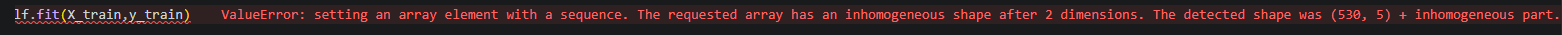

But apparently, numpy & sklearn have problems with our feature_set which is a list of lists with tuples of these different sizes.. They want a flat, uniform 2d numerical matrix with like rows & columns, but we're feeding it rows with like nested groups of different dimensions...

So I guess the only way we could go about this is having the tuples into like a 2d array (list of lists) or something...

In [ ]:
two_dim_feature_set = []

for one_sec_window in feature_set:
    flattened_window_sample = []
    for sub_tuple in one_sec_window:
        flattened_window_sample.extend(sub_tuple) # extend over append here, as we need to iterate over the tuple 
    two_dim_feature_set.append(flattened_window_sample)

print(two_dim_feature_set[:10])

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(two_dim_feature_set,target_set,random_state=0)

# including hyperparams... I think; wikipedia mentions: 
# In machine learning, a hyperparameter is a parameter that can be set in order to define any
# configurable part of a model's learning process. Hyperparameters can be classified as either
# model hyperparameters (such as the topology and size of a neural network) or algorithm 
# hyperparameters (such as the learning rate and the batch size of an optimizer). 
# These are named hyperparameters in contrast to parameters, which are characteristics that the 
# model learns from the data.
# & so we are directly changing the learning rate with alpha + like batch size etc...
# Just go over the sources & write out a detailed explanation for the hyperparams for SGD:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html
# https://medium.com/@juanc.olamendy/sgdclassifier-the-powerhouse-for-large-scale-classification-9ae2369d57fb
# https://www.geeksforgeeks.org/python/stochastic-gradient-descent-classifier/
# https://en.wikipedia.org/wiki/Hyperparameter_(machine_learning)
# also worth having a look at this as well:
# https://www.geeksforgeeks.org/machine-learning/difference-between-batch-gradient-descent-and-stochastic-gradient-descent/
# seems as though I keep going deeper & deeper to find more interesting things; Look at the 
# mini-batch here: https://medium.com/@juanc.olamendy/mini-batch-gradient-descent-optimizing-machine-learning-98ef238c5225
# https://www.kaggle.com/code/eissaislam/linear-regression-using-batch-gradient-descent
sgd_clf = Pipeline([("scaler",StandardScaler()),("sgd",SGDClassifier(loss='log_loss',
                                                                     penalty='l2',alpha=0.00001,
                                                                     random_state=0))])

sgd_clf.fit(X_train,y_train)

# run predictions for 5 fold cv:
y_pred = cross_val_predict(sgd_clf,X_train,y_train,cv=5)

# predictions for test set:
y_test_pred = sgd_clf.predict(X_test)

conf_matrix_train = confusion_matrix(y_train,y_pred)
conf_matrix_test = confusion_matrix(y_test,y_test_pred)

# printing out recall, precision & f1 scores...
# just note that there is a value for each calss:
print("CV Train Recall:", recall_score(y_train,y_pred,average=None))
print("CV Train Precision:",precision_score(y_train,y_pred,average=None))
print("CV Train F1 Score:",f1_score(y_train,y_pred,average=None))

# Test
print("Test Recall:",recall_score(y_test,y_test_pred,average=None))
print("Test Precision:",precision_score(y_test,y_test_pred,average=None))
print("Test F1 Score:",f1_score(y_test,y_test_pred,average=None))

# plotting confusion matrices:
fig,ax = plt.subplots()
disp = ConfusionMatrixDisplay.from_estimator(sgd_clf,X_train,y_train,
                                             display_labels=['Standing','Walking','Side-Step','Running','Jogging'],
                                             cmap=plt.cm.Oranges,ax=ax)

# rotating the labels so that they are able to be read:
for tick in ax.get_xticklabels():
    tick.set_rotation(45)

ax.set_title('5 Fold Training')

fig,ax = plt.subplots()
disp = ConfusionMatrixDisplay.from_estimator(sgd_clf,X_test,y_test,
                                             display_labels=['Standing','Walking','Side-Step','Running','Jogging'],
                                             cmap=plt.cm.Oranges,ax=ax)

for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    
ax.set_title("Classifier performance on test set")

Now we should have every like one second window as one list in this list of lists... and every one second window will contain the 6 + 6 + 6 + 2 + 2 = 22 features...

In [ ]:
# just visualising the ROC curves + learnt decision boundaries w/ training data:

y_scores = sgd_clf.decision_function(X_test)

y_test_bin = label_binarize(y_test,classes=[0,1,2,3,4])

fpr = dict()
tpr = dict()
roc_auc = dict()

fig,ax = plt.subplots()
colours_for_curves = ['red','blue','green','orange','purple']

for i in range(5):
    fpr[i],tpr[i],_ = roc_curve(y_test_bin[:,i],y_scores[:,i])
    
    roc_auc[i] = auc(fpr[i],tpr[i])
    
    ax.plot(fpr[i],tpr[i],color=colours_for_curves[i],
            label=(f"Class = {i}, AUC = {roc_auc[i]:.3f}"))

plt.legend(loc=4)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title("Roc Curves for our 5 classes to evalute SGDClassifier",fontweight="bold")


Well our classifier was trained on the 22 features, & we can't really just visualise 22d data... So let's just use the first two features... And even then just note that the decision boundary will represent like if 20 features were average values, and we only looked at the 2 selected features then this is what decision boundaries look like....

### TODO: So im thinking maybe we can replicate like something we did in at2 to select the best 2 features that would be able to give us the best decision boundary;

In [ ]:
# note that our X_test etc. is a python list, so we can't do like X_test.min() because we'll get an err
# so we need to convert to np array first:
X_test = np.array(X_test)
X_train = np.array(X_train)
y_test = np.array(y_test)
y_train = np.array(y_train)

x_feature = 20
y_feature = 21

x_min, x_max = X_test[:,x_feature].min() - 1, X_test[:,x_feature].max() + 1
y_min, y_max = X_test[:,y_feature].min() - 1, X_test[:,y_feature].max() + 1

xx,yy = np.meshgrid(np.linspace(x_min,x_max,500),np.linspace(y_min,y_max,500))

# creating 22 feature vector for all points in grid.... we first just start by setting every feature to its mean val:
grid_points = np.tile(X_train.mean(axis=0), (xx.ravel().shape[0],1))

grid_points[:,x_feature] = xx.ravel()
grid_points[:,y_feature] = yy.ravel()

grid_predictions = sgd_clf.predict(grid_points)

grid_predictions = grid_predictions.reshape(xx.shape)

fig,ax = plt.subplots()

ax.contourf(xx,yy,grid_predictions,cmap="rainbow")

scatter_points = ax.scatter(X_test[:,x_feature],X_test[:,y_feature],c=y_test,cmap="rainbow",edgecolor="black")
ax.legend(*scatter_points.legend_elements(),title="Class")

ax.set_xlabel(f"Feature {x_feature}")
ax.set_ylabel(f"Feature {y_feature}")

ax.set_title("Decision Boundaries Learnt by SGDClassifier", fontweight="bold")
plt.show()

---

# Section 4. Conclusion

*All members*